# Preprocessing of application columns for baseline logistic regression
- table - app_train.csv, app_valid.csv
---

Preparing data set for modeling with baseline logistic regression
1. Removing unnecessary columns
2. Basic grouping for categorical variables
3. Grouping discrete variables
4. Imputing missing values and creating missing flags
5. Handling special values
6. Maping binary cols to 0, 1 values
7. Creating interactions (to do)
8. Saving preprocessed data set

## 0. Libaries and data

In [841]:
import pandas as pd
import numpy as np

import sys
from pathlib import Path

from sklearn.model_selection import train_test_split

In [842]:
def _build_invalid_mask(
    series: pd.Series,
    invalid_value=None,
    invalid_condition=None
) -> pd.Series:
    """
    Build boolean mask of invalid values.

    Supported:
    - invalid_value=365243
    - invalid_condition='< 0'
    - invalid_condition='<= -1'
    - invalid_condition='== 365243'
    - invalid_condition=lambda s: s < 0
    """

    mask = pd.Series(False, index=series.index)

    if invalid_value is not None:
        if isinstance(invalid_value, (list, tuple, set, np.ndarray, pd.Series)):
            mask |= series.isin(invalid_value)
        else:
            mask |= series.eq(invalid_value)

    if invalid_condition is not None:
        if callable(invalid_condition):
            cond_mask = invalid_condition(series)
            if not isinstance(cond_mask, pd.Series):
                cond_mask = pd.Series(cond_mask, index=series.index)
            mask |= cond_mask.fillna(False)

        elif isinstance(invalid_condition, str):
            condition = invalid_condition.strip()

            ops = {
                "<": operator.lt,
                "<=": operator.le,
                ">": operator.gt,
                ">=": operator.ge,
                "==": operator.eq,
                "!=": operator.ne,
            }

            matched_op = None
            for op_symbol in ["<=", ">=", "==", "!=", "<", ">"]:
                if condition.startswith(op_symbol):
                    matched_op = op_symbol
                    threshold_str = condition[len(op_symbol):].strip()
                    break

            if matched_op is None:
                raise ValueError(
                    f"Unsupported invalid_condition: {invalid_condition!r}. "
                    "Use forms like '< 0', '== 365243', '>= 1000', "
                    "or pass a callable."
                )

            try:
                threshold = float(threshold_str)
            except ValueError as e:
                raise ValueError(
                    f"Could not parse threshold in invalid_condition: {invalid_condition!r}"
                ) from e

            mask |= ops[matched_op](series, threshold).fillna(False)

        else:
            raise TypeError(
                "invalid_condition must be either a string, a callable, or None."
            )

    return mask.fillna(False)

In [843]:
from typing import Optional

def create_imputed_quantitative_features(
    df: pd.DataFrame,
    value_col: str,
    specs: dict,
    df_valid: Optional[pd.DataFrame] = None,
    invalid_value=None,
    invalid_condition=None,
    add_invalid_flag: bool = True,
    add_clean_col: bool = True,
    return_summary: bool = True
):
    """
    Create multiple imputed versions of one quantitative variable using grouped
    and hierarchical rules.

    The imputation statistics are learned on `df` only and then applied to:
    - `df`
    - `df_valid`, if provided

    Parameters
    ----------
    df : pd.DataFrame
        Training dataframe used to fit imputation statistics.
    value_col : str
        Column to impute.
    specs : dict
        Dictionary where keys are output column names and values are dicts with:
            - method: 'median' or 'mean'
            - group_levels: list of grouping-column lists

        Example
        -------
        {
            "DAYS_EMPLOYED_imp_1": {
                "method": "median",
                "group_levels": []
            },
            "DAYS_EMPLOYED_imp_2": {
                "method": "median",
                "group_levels": [["NAME_INCOME_TYPE"]]
            },
            "DAYS_EMPLOYED_imp_3": {
                "method": "median",
                "group_levels": [["NAME_INCOME_TYPE", "CODE_GENDER"], ["NAME_INCOME_TYPE"]]
            }
        }

    df_valid : pd.DataFrame, optional
        Validation dataframe to transform using statistics learned on `df`.

    invalid_value : scalar or iterable, optional
        Exact value(s) treated as invalid.
    invalid_condition : str or callable, optional
        Broader invalid rule, e.g. '< 0', '== 365243',
        or lambda s: (s < 0) | (s == 365243)

    add_invalid_flag : bool, default=True
        Whether to create {value_col}_invalid.
    add_clean_col : bool, default=True
        Whether to create {value_col}_clean.
    return_summary : bool, default=True
        Whether to return imputation diagnostics for the training dataframe.

    Returns
    -------
    If df_valid is None:
        df_out : pd.DataFrame
        summary_df : pd.DataFrame, optional

    If df_valid is provided:
        df_out : pd.DataFrame
        df_valid_out : pd.DataFrame
        summary_df : pd.DataFrame, optional

    Notes
    -----
    - Imputation is fitted on `df` only.
    - `df_valid` is transformed using group statistics and global fallback learned from `df`.
    - This avoids data leakage from validation into training preprocessing.
    """

    if df.shape[0] == 0:
        raise ValueError("Input dataframe `df` has no rows.")
    if df.shape[1] == 0:
        raise ValueError("Input dataframe `df` has no columns.")
    if value_col not in df.columns:
        raise KeyError(f"Column '{value_col}' not found in df.")

    if df_valid is not None:
        if df_valid.shape[1] == 0:
            raise ValueError("Input dataframe `df_valid` has no columns.")
        if value_col not in df_valid.columns:
            raise KeyError(f"Column '{value_col}' not found in df_valid.")

    df_out = df.copy()
    df_valid_out = df_valid.copy() if df_valid is not None else None

    clean_col = f"{value_col}_clean"
    invalid_flag_col = f"{value_col}_invalid"

    # Build invalid masks
    invalid_mask_train = _build_invalid_mask(
        df_out[value_col],
        invalid_value=invalid_value,
        invalid_condition=invalid_condition
    )

    if df_valid_out is not None:
        invalid_mask_valid = _build_invalid_mask(
            df_valid_out[value_col],
            invalid_value=invalid_value,
            invalid_condition=invalid_condition
        )

    # Add invalid flag
    if add_invalid_flag:
        df_out[invalid_flag_col] = invalid_mask_train.astype(int)
        if df_valid_out is not None:
            df_valid_out[invalid_flag_col] = invalid_mask_valid.astype(int)

    # Create clean column
    df_out[clean_col] = df_out[value_col].mask(invalid_mask_train, np.nan)
    if df_valid_out is not None:
        df_valid_out[clean_col] = df_valid_out[value_col].mask(invalid_mask_valid, np.nan)

    summary_rows = []

    for output_col, config in specs.items():
        method = config.get("method", "median")
        group_levels = config.get("group_levels", [])

        if method not in {"median", "mean"}:
            raise ValueError(
                f"Unsupported method {method!r} for {output_col}. Use 'median' or 'mean'."
            )

        # Start from clean values
        df_out[output_col] = df_out[clean_col].copy()
        if df_valid_out is not None:
            df_valid_out[output_col] = df_valid_out[clean_col].copy()

        step_counts_train = []
        step_counts_valid = []

        missing_before_train = df_out[output_col].isna().sum()
        missing_before_valid = (
            df_valid_out[output_col].isna().sum() if df_valid_out is not None else None
        )

        # Hierarchical/grouped fills learned on train only
        for step_idx, group_cols in enumerate(group_levels, start=1):
            if not group_cols:
                continue

            for group_col in group_cols:
                if group_col not in df_out.columns:
                    raise KeyError(f"Grouping column '{group_col}' not found in df.")
                if df_valid_out is not None and group_col not in df_valid_out.columns:
                    raise KeyError(f"Grouping column '{group_col}' not found in df_valid.")

            fill_values = (
                df_out.groupby(group_cols, dropna=False)[clean_col]
                .agg(method)
                .rename("_fill_value")
                .reset_index()
            )

            # Apply to train
            df_out = df_out.merge(fill_values, on=group_cols, how="left")
            na_before_step_train = df_out[output_col].isna()
            df_out[output_col] = df_out[output_col].fillna(df_out["_fill_value"])
            filled_now_train = na_before_step_train.sum() - df_out[output_col].isna().sum()

            step_counts_train.append({
                "dataset": "train",
                "output_col": output_col,
                "step": step_idx,
                "group_level": tuple(group_cols),
                "filled_count": int(filled_now_train),
            })

            df_out = df_out.drop(columns=["_fill_value"])

            # Apply same learned fill values to valid
            if df_valid_out is not None:
                df_valid_out = df_valid_out.merge(fill_values, on=group_cols, how="left")
                na_before_step_valid = df_valid_out[output_col].isna()
                df_valid_out[output_col] = df_valid_out[output_col].fillna(df_valid_out["_fill_value"])
                filled_now_valid = (
                    na_before_step_valid.sum() - df_valid_out[output_col].isna().sum()
                )

                step_counts_valid.append({
                    "dataset": "valid",
                    "output_col": output_col,
                    "step": step_idx,
                    "group_level": tuple(group_cols),
                    "filled_count": int(filled_now_valid),
                })

                df_valid_out = df_valid_out.drop(columns=["_fill_value"])

        # Global fallback learned on train only
        global_fill = getattr(df_out[clean_col], method)()

        na_before_global_train = df_out[output_col].isna().sum()
        df_out[output_col] = df_out[output_col].fillna(global_fill)
        global_filled_train = na_before_global_train - df_out[output_col].isna().sum()

        if df_valid_out is not None:
            na_before_global_valid = df_valid_out[output_col].isna().sum()
            df_valid_out[output_col] = df_valid_out[output_col].fillna(global_fill)
            global_filled_valid = (
                na_before_global_valid - df_valid_out[output_col].isna().sum()
            )

        summary_rows.append({
            "dataset": "train",
            "output_col": output_col,
            "method": method,
            "n_invalid": int(invalid_mask_train.sum()),
            "missing_before_imputation": int(missing_before_train),
            "filled_by_hierarchy": int(sum(row["filled_count"] for row in step_counts_train)),
            "filled_by_global": int(global_filled_train),
            "missing_after_imputation": int(df_out[output_col].isna().sum()),
            "group_levels": str(group_levels),
        })

        summary_rows.extend(step_counts_train)

        if df_valid_out is not None:
            summary_rows.append({
                "dataset": "valid",
                "output_col": output_col,
                "method": method,
                "n_invalid": int(invalid_mask_valid.sum()),
                "missing_before_imputation": int(missing_before_valid),
                "filled_by_hierarchy": int(sum(row["filled_count"] for row in step_counts_valid)),
                "filled_by_global": int(global_filled_valid),
                "missing_after_imputation": int(df_valid_out[output_col].isna().sum()),
                "group_levels": str(group_levels),
            })

            summary_rows.extend(step_counts_valid)

    if not add_clean_col:
        df_out = df_out.drop(columns=[clean_col])
        if df_valid_out is not None:
            df_valid_out = df_valid_out.drop(columns=[clean_col])

    summary_df = pd.DataFrame(summary_rows)

    if return_summary:
        if df_valid_out is not None:
            return df_out, df_valid_out, summary_df
        return df_out, summary_df

    if df_valid_out is not None:
        return df_out, df_valid_out
    return df_out

In [844]:
app_df = pd.read_csv(r"data/application_train.csv")
print(f"Shape of app_df: {app_df.shape}")
app_df.head(10)

Shape of app_df: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,...,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,...,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,...,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-815.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,NaN,1,1,0,1,0,0,Laborers,2.0,2,2,WEDNESDAY,17,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,2.0,0.0,-617.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.028663,-19932,-3038,-4311.0,-3458,NaN,1,1,0,1,0,0,Core staff,1.0,2,2,THURSDAY,11,0,0,0,0,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-1106.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
5,100008,0,Cash loans,M,N,Y,0,99000.0,490495.5,27517.5,454500.0,"Spouse, partner",State servant,Secondary / secondary special,Married,House / apartment,0.035792,-16941,-1588,-4970.0,-477,NaN,1,1,1,1,1,0,Laborers,2.0,2,2,WEDNESDAY,16,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-2536.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0
6,100009,0,Cash loans,F,Y,Y,1,171000.0,1560726.0,41301.0,1395000.0,Unaccompanied,Commercial associate,Higher education,Married,House / apartment,0.035792,-13778,-3130,-1213.0,-619,17.0,1,1,0,1,1,0,Acco

In [845]:
X, y = app_df.drop(columns=['TARGET']), app_df['TARGET']
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

print(f"X_train: {X_train.shape}")
print(f"X_valid: {X_valid.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_valid: {y_valid.shape}")

X_train: (215257, 121)
X_valid: (92254, 121)
y_train: (215257,)
y_valid: (92254,)


In [846]:
assert X_train.index.equals(y_train.index)
assert X_valid.index.equals(y_valid.index)

app_train_df = X_train.join(y_train)
app_valid_df = X_valid.join(y_valid)

In [847]:
df_train = app_train_df
print(f"Shape of df_train: {df_train.shape}")
print(f"Unique dtypes of df_train: {df_train.dtypes.unique()}")
df_train.head(10)

Shape of df_train: (215257, 122)
Unique dtypes of df_train: [dtype('int64') dtype('O') dtype('float64')]


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,...,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,TARGET
159703,285133,Cash loans,F,Y,Y,2,405000.0,1971072.0,68643.0,1800000.0,Unaccompanied,Commercial associate,Higher education,Married,House / apartment,0.006852,-13587,-1028,-7460.0,-1823,13.0,1,1,0,1,0,0,Accountants,4.0,3,3,SATURDAY,11,0,0,0,0,0,0,Self-employed,...,0.1265,NaN,0.0293,reg oper account,block of flats,0.1039,"Stone, brick",No,4.0,0.0,4.0,0.0,-2169.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0
79269,191894,Cash loans,M,N,Y,0,337500.0,508495.5,38146.5,454500.0,Family,State servant,Higher education,Married,House / apartment,0.010276,-17543,-1208,-4054.0,-1090,NaN,1,1,0,1,0,0,Managers,2.0,2,2,WEDNESDAY,11,0,0,0,0,0,0,Agriculture,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.0,2.0,1.0,-659.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,6.0,0
232615,369428,Cash loans,M,N,Y,1,112500.0,110146.5,13068.0,90000.0,Unaccompanied,Commercial associate,Secondary / secondary special,Married,House / apartment,0.005084,-11557,-593,-5554.0,-4130,NaN,1,1,0,1,1,1,Laborers,3.0,2,2,FRIDAY,11,0,0,0,0,0,0,Business Entity Type 3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-172.0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
33420,138717,Cash loans,F,N,Y,2,40500.0,66384.0,3519.0,45000.0,Unaccompanied,Commercial associate,Secondary / secondary special,Married,House / apartment,0.031329,-15750,-5376,-5285.0,-5290,NaN,1,1,0,1,0,0,Sales staff,4.0,2,2,TUESDAY,13,0,0,0,0,0,0,Self-employed,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-1576.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,1.0,0.0,2.0,0
88191,202381,Cash loans,M,Y,N,0,225000.0,298512.0,31801.5,270000.0,Unaccompanied,Commercial associate,Secondary / secondary special,Married,House / apartment,0.019101,-19912,-1195,-86.0,-3033,11.0,1,1,0,1,0,0,Drivers,2.0,2,2,FRIDAY,16,0,0,0,0,0,0,Construction,...,0.2523,0.0039,0.0017,reg oper account,block of flats,0.2733,"Stone, brick",No,3.0,0.0,3.0,0.0,-624.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0
73952,185763,Cash loans,F,N,Y,0,315000.0,417024.0,21964.5,360000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010147,-15714,-5116,-165.0,-3973,NaN,1,1,0,1,0,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Industry: type 7,...,0.0253,NaN,0.0000,reg oper account,block of flats,0.0196,Panel,No,0.0,0.0,0.0,0.0,-654.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0,0
42122,148765,Cash loans,M,Y,Y,0,162000.0,168102.0,11362.5,148500.0,"Spouse, partner",W

In [848]:
df_valid = app_valid_df
print(f"Shape of df_valid: {df_valid.shape}")
print(f"Unique dtypes of df_valid: {df_valid.dtypes.unique()}")
df_valid.head(10)

Shape of df_valid: (92254, 122)
Unique dtypes of df_valid: [dtype('int64') dtype('O') dtype('float64')]


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,...,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,TARGET
199280,331034,Cash loans,F,N,Y,0,90000.0,803259.0,23616.0,670500.0,Family,Working,Secondary / secondary special,Married,House / apartment,0.008625,-19596,-1873,-10088.0,-3130,NaN,1,1,1,1,0,0,NaN,2.0,2,2,SATURDAY,16,0,0,0,0,0,0,School,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,0.0,3.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,1.0,0.0,1.0,0
122967,242581,Cash loans,F,N,Y,0,270000.0,1288350.0,41692.5,1125000.0,Unaccompanied,Working,Higher education,Married,House / apartment,0.008019,-13853,-1070,-670.0,-4712,NaN,1,1,0,1,0,0,Managers,2.0,2,2,SATURDAY,13,0,0,0,0,0,0,Housing,...,0.0772,0.0000,0.0000,not specified,block of flats,0.0794,Panel,No,2.0,0.0,2.0,0.0,-1785.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,1.0,0.0,4.0,0
156663,281583,Cash loans,F,N,Y,0,270000.0,253737.0,25227.0,229500.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.020246,-20895,-1477,-5773.0,-4370,NaN,1,1,0,1,0,0,NaN,2.0,3,3,WEDNESDAY,8,0,0,0,0,0,0,Business Entity Type 3,...,0.2858,0.0116,0.0448,reg oper account,block of flats,0.2032,Panel,No,2.0,0.0,2.0,0.0,-1282.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
134382,255865,Cash loans,F,N,Y,0,144000.0,436032.0,16564.5,360000.0,Unaccompanied,Commercial associate,Secondary / secondary special,Married,House / apartment,0.018850,-18859,-916,-5972.0,-2416,NaN,1,1,0,1,1,0,NaN,2.0,2,2,SATURDAY,12,0,0,0,0,0,0,Business Entity Type 3,...,0.0991,NaN,NaN,NaN,block of flats,0.0766,"Stone, brick",No,1.0,1.0,1.0,1.0,-920.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,1.0,0.0,0.0,2.0,0
250108,389379,Revolving loans,M,N,N,2,72000.0,225000.0,11250.0,225000.0,Unaccompanied,Working,Secondary / secondary special,Married,With parents,0.019101,-16521,-2786,-6337.0,-19,NaN,1,1,0,1,0,0,Laborers,4.0,2,2,THURSDAY,16,0,0,0,1,1,0,Business Entity Type 3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-392.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
306843,455506,Cash loans,M,Y,Y,0,315000.0,521280.0,27423.0,450000.0,Unaccompanied,Commercial associate,Secondary / secondary special,Single / not married,Rented apartment,0.031329,-10318,-2069,-1727.0,-1736,64.0,1,1,0,1,0,0,NaN,1.0,2,2,MONDAY,14,0,0,0,0,0,0,Self-employed,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-1338.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2.0,0
116315,234885,Cash loans,F,Y,Y,1,54000.0,102384.0,6673.5,81000.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartmen

## 1. Removing all unnecessary columns
- technical columns
- columns with one value
- columns with high number of NANs

In [849]:
df_train1 = df_train.copy()
df_valid1 = df_valid.copy()

In [850]:
max_acceptable_nan_share = 0.50
high_corr_candidates = {}

In [851]:
credit_bureau_cols = [
    'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
    'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR'
]

building_cols = [
    'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG',
    'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG',
    'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG',
    'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 

    'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE',
    'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE',
    'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE',
    'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE',

    'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI',
    'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI',
    'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI',
    'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI',

    'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'TOTALAREA_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'
]

In [852]:
cols_to_keep = ['EXT_SOURCE_1']

cols_to_remove = [
    'SK_ID_CURR',
    'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START',

    'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
    'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',

    'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG',
    'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG',
    'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG',
    'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 

    'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE',
    'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE',
    'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE',
    'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE',

    'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI',
    'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI',
    'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI',
    'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI',

    'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'TOTALAREA_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'
]


In [853]:
df_train1['OWN_CAR_AGE_missing'] = np.where(df_train1['OWN_CAR_AGE'].isna(), 1, 0)
df_valid1['OWN_CAR_AGE_missing'] = np.where(df_valid1['OWN_CAR_AGE'].isna(), 1, 0)

In [854]:
df_train_nans = df_train1.isna().mean().to_frame(name='nan_train').reset_index()
df_train_nans[df_train_nans['nan_train']>0]

,index,nan_train
8,AMT_ANNUITY,0.000037
9,AMT_GOODS_PRICE,0.000869
10,NAME_TYPE_SUITE,0.004186
20,OWN_CAR_AGE,0.660099
27,OCCUPATION_TYPE,0.313486
...,...,...
116,AMT_REQ_CREDIT_BUREAU_DAY,0.135099
117,AMT_REQ_CREDIT_BUREAU_WEEK,0.135099
118,AMT_REQ_CREDIT_BUREAU_MON,0.135099
119,AMT_REQ_CREDIT_BUREAU_QRT,0.135099


In [855]:
high_nan_cols = list(df_train_nans[
    (df_train_nans['nan_train']>max_acceptable_nan_share) 
]['index'].values)

high_nan_cols

['OWN_CAR_AGE',
 'EXT_SOURCE_1',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BUILD_AVG',
 'COMMONAREA_AVG',
 'ELEVATORS_AVG',
 'ENTRANCES_AVG',
 'FLOORSMIN_AVG',
 'LANDAREA_AVG',
 'LIVINGAPARTMENTS_AVG',
 'LIVINGAREA_AVG',
 'NONLIVINGAPARTMENTS_AVG',
 'NONLIVINGAREA_AVG',
 'APARTMENTS_MODE',
 'BASEMENTAREA_MODE',
 'YEARS_BUILD_MODE',
 'COMMONAREA_MODE',
 'ELEVATORS_MODE',
 'ENTRANCES_MODE',
 'FLOORSMIN_MODE',
 'LANDAREA_MODE',
 'LIVINGAPARTMENTS_MODE',
 'LIVINGAREA_MODE',
 'NONLIVINGAPARTMENTS_MODE',
 'NONLIVINGAREA_MODE',
 'APARTMENTS_MEDI',
 'BASEMENTAREA_MEDI',
 'YEARS_BUILD_MEDI',
 'COMMONAREA_MEDI',
 'ELEVATORS_MEDI',
 'ENTRANCES_MEDI',
 'FLOORSMIN_MEDI',
 'LANDAREA_MEDI',
 'LIVINGAPARTMENTS_MEDI',
 'LIVINGAREA_MEDI',
 'NONLIVINGAPARTMENTS_MEDI',
 'NONLIVINGAREA_MEDI',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE']

In [856]:
cols_to_remove = cols_to_remove + high_nan_cols
cols_to_remove = [col for col in cols_to_remove if col not in cols_to_keep]
cols_to_remove

['SK_ID_CURR',
 'WEEKDAY_APPR_PROCESS_START',
 'HOUR_APPR_PROCESS_START',
 'AMT_REQ_CREDIT_BUREAU_HOUR',
 'AMT_REQ_CREDIT_BUREAU_DAY',
 'AMT_REQ_CREDIT_BUREAU_WEEK',
 'AMT_REQ_CREDIT_BUREAU_MON',
 'AMT_REQ_CREDIT_BUREAU_QRT',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_AVG',
 'YEARS_BUILD_AVG',
 'COMMONAREA_AVG',
 'ELEVATORS_AVG',
 'ENTRANCES_AVG',
 'FLOORSMAX_AVG',
 'FLOORSMIN_AVG',
 'LANDAREA_AVG',
 'LIVINGAPARTMENTS_AVG',
 'LIVINGAREA_AVG',
 'NONLIVINGAPARTMENTS_AVG',
 'NONLIVINGAREA_AVG',
 'APARTMENTS_MODE',
 'BASEMENTAREA_MODE',
 'YEARS_BEGINEXPLUATATION_MODE',
 'YEARS_BUILD_MODE',
 'COMMONAREA_MODE',
 'ELEVATORS_MODE',
 'ENTRANCES_MODE',
 'FLOORSMAX_MODE',
 'FLOORSMIN_MODE',
 'LANDAREA_MODE',
 'LIVINGAPARTMENTS_MODE',
 'LIVINGAREA_MODE',
 'NONLIVINGAPARTMENTS_MODE',
 'NONLIVINGAREA_MODE',
 'APARTMENTS_MEDI',
 'BASEMENTAREA_MEDI',
 'YEARS_BEGINEXPLUATATION_MEDI',
 'YEARS_BUILD_MEDI',
 'COMMONAREA_MEDI',
 'ELEVATORS_MEDI',
 'ENTRANCES_MEDI',
 'FLOORSMAX_MEDI',

In [857]:
print(f"df_train1: {df_train1.shape}")
print(f"df_valid1: {df_valid1.shape}")

df_train1: (215257, 123)
df_valid1: (92254, 123)


In [858]:
df_train1 = df_train1.drop(columns=cols_to_remove)
df_valid1 = df_valid1.drop(columns=cols_to_remove)

In [859]:
print(f"df_train1: {df_train1.shape}")
print(f"df_valid1: {df_valid1.shape}")

df_train1: (215257, 67)
df_valid1: (92254, 67)


In [860]:
binary_cols = [col for col in df_train1.columns if df_train1[col].nunique()==2]
num_cols = list(df_train1.select_dtypes(include=['Int64', 'float64']).columns)
num_cols = [col for col in num_cols if col not in binary_cols]
cat_cols = list(df_train1.select_dtypes(include=['O']).columns)
cat_cols = [col for col in cat_cols if col not in binary_cols]


print(f"len(num_cols) + len(cat_cols) + len(binary_cols) == df_train1.shape[1]: {(len(num_cols) + len(cat_cols) + len(binary_cols)) == df_train1.shape[1]}")
print(f"Number of binary columns: {len(binary_cols)}")

len(num_cols) + len(cat_cols) + len(binary_cols) == df_train1.shape[1]: True
Number of binary columns: 37


## 2. Basic grouping for categorical columns

Max number of categories withn one variable and min share of minory category:

In [861]:
max_cat_n = 4
min_cat_share = 0.05

In [862]:
df_train2 = df_train1.copy()
df_valid2 = df_valid1.copy()

In [863]:
cat_cols_to_group = [col for col in cat_cols if df_train2[col].nunique() > 4]
print(cat_cols_to_group)

['NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE']


In [864]:
for col in cat_cols_to_group:
    print(f"Variable: {col}\n")
    
    df_train_grouped = df_train2[[col, 'TARGET']].groupby(col).agg(
            n_obs = (col, 'count'),
            target_share = ('TARGET', 'mean')
    )
    df_train_grouped['obs_share'] = round(df_train_grouped['n_obs'] / df_train2.shape[0],4)
    df_train_grouped['target_share'] = df_train_grouped['target_share'].round(4)
    print(df_train_grouped[['n_obs', 'obs_share', 'target_share']])
    print('-' * 60)

Variable: NAME_TYPE_SUITE

                  n_obs  obs_share  target_share
NAME_TYPE_SUITE                                 
Children           2327     0.0108        0.0743
Family            28001     0.1301        0.0734
Group of people     198     0.0009        0.0859
Other_A             614     0.0029        0.0896
Other_B            1248     0.0058        0.0994
Spouse, partner    7879     0.0366        0.0787
Unaccompanied    174089     0.8087        0.0820
------------------------------------------------------------
Variable: NAME_INCOME_TYPE

                       n_obs  obs_share  target_share
NAME_INCOME_TYPE                                     
Businessman                9     0.0000        0.0000
Commercial associate   50106     0.2328        0.0758
Maternity leave            3     0.0000        0.0000
Pensioner              38748     0.1800        0.0539
State servant          15382     0.0715        0.0589
Student                    9     0.0000        0.0000
Unemployed 

In [865]:
categories_to_group = {}
special_grouping_cols = []

for col in cat_cols_to_group:
    print(f"Variable: {col}")
    
    df_train_grouped = df_train2[[col, 'TARGET']].groupby(col).agg(
            n_obs = (col, 'count'),
            target_share = ('TARGET', 'mean')
    )
    df_train_grouped['obs_share'] = round(df_train_grouped['n_obs'] / df_train2.shape[0],4)
    df_train_grouped['target_share'] = df_train_grouped['target_share'].round(4)

    minor_cat_share = df_train_grouped[
        df_train_grouped['obs_share'] < 0.05
    ]['obs_share'].sum()

    categories_to_group[col] = list(df_train_grouped[df_train_grouped['obs_share']< 0.05].index)
    
    if minor_cat_share < 0.05:
        min_acceptable_share = df_train_grouped[df_train_grouped['obs_share']>=0.05]['obs_share'].min()
        other_canidadate = df_train_grouped[df_train_grouped['obs_share']==min_acceptable_share].index[0]
        categories_to_group[col].append(other_canidadate)
        special_grouping_cols.append(col)


    print('-' * 60)
    print(f"Share of minor categories: {minor_cat_share}\n")
    print(df_train_grouped[df_train_grouped['obs_share']< 0.05][['n_obs', 'obs_share', 'target_share']])
    print('-' * 60)

Variable: NAME_TYPE_SUITE
------------------------------------------------------------
Share of minor categories: 0.057

                 n_obs  obs_share  target_share
NAME_TYPE_SUITE                                
Children          2327     0.0108        0.0743
Group of people    198     0.0009        0.0859
Other_A            614     0.0029        0.0896
Other_B           1248     0.0058        0.0994
Spouse, partner   7879     0.0366        0.0787
------------------------------------------------------------
Variable: NAME_INCOME_TYPE
------------------------------------------------------------
Share of minor categories: 0.0001

                  n_obs  obs_share  target_share
NAME_INCOME_TYPE                                
Businessman           9     0.0000        0.0000
Maternity leave       3     0.0000        0.0000
Student               9     0.0000        0.0000
Unemployed           16     0.0001        0.3125
------------------------------------------------------------
Vari

In [866]:
print(categories_to_group)
print(len(categories_to_group))

{'NAME_TYPE_SUITE': ['Children', 'Group of people', 'Other_A', 'Other_B', 'Spouse, partner'], 'NAME_INCOME_TYPE': ['Businessman', 'Maternity leave', 'Student', 'Unemployed', 'State servant'], 'NAME_EDUCATION_TYPE': ['Academic degree', 'Incomplete higher', 'Lower secondary', 'Higher education'], 'NAME_FAMILY_STATUS': ['Unknown', 'Widow'], 'NAME_HOUSING_TYPE': ['Co-op apartment', 'Municipal apartment', 'Office apartment', 'Rented apartment', 'With parents'], 'OCCUPATION_TYPE': ['Accountants', 'Cleaning staff', 'Cooking staff', 'HR staff', 'High skill tech staff', 'IT staff', 'Low-skill Laborers', 'Medicine staff', 'Private service staff', 'Realty agents', 'Secretaries', 'Security staff', 'Waiters/barmen staff'], 'ORGANIZATION_TYPE': ['Advertising', 'Agriculture', 'Bank', 'Business Entity Type 1', 'Business Entity Type 2', 'Cleaning', 'Construction', 'Culture', 'Electricity', 'Emergency', 'Government', 'Hotel', 'Housing', 'Industry: type 1', 'Industry: type 10', 'Industry: type 11', 'Indu

In [867]:
print(special_grouping_cols)
print(len(special_grouping_cols))
    

['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS']
3


### 2.1 Grouping all minor categories into 'other'

In [868]:
df_train2_1 = df_train2.copy()
df_valid2_1 = df_valid2.copy()

In [869]:
print(f"df_train2_1: {df_train2_1.shape}")
print(f"df_valid2_1: {df_valid2_1.shape}")

df_train2_1: (215257, 67)
df_valid2_1: (92254, 67)


In [870]:
for col in categories_to_group.keys():
    if col not in special_grouping_cols:
        df_train2_1[f"{col}_grouped"] = np.where(
            df_train2_1[col].isin(categories_to_group[col]),
            'other',
            df_train2_1[col]
        )
        df_valid2_1[f"{col}_grouped"] = np.where(
            df_valid2_1[col].isin(categories_to_group[col]),
            'other',
            df_valid2_1[col]
        )

        if col != 'OCCUPATION_TYPE':                      # OCCUPATION_TYPE dropped later
            df_train2_1 = df_train2_1.drop(columns=[col])
            df_valid2_1 = df_valid2_1.drop(columns=[col])
        print(col)


NAME_TYPE_SUITE
NAME_HOUSING_TYPE
OCCUPATION_TYPE
ORGANIZATION_TYPE


In [871]:
for col in cat_cols_to_group:
    if col not in special_grouping_cols:
        col = f"{col}_grouped"
        print(f"Variable: {col}")
        print(df_train2_1[col].value_counts() / df_train2_1.shape[0])
        print("-"*60)

Variable: NAME_TYPE_SUITE_grouped
NAME_TYPE_SUITE_grouped
Unaccompanied    0.808750
Family           0.130082
other            0.056983
Name: count, dtype: float64
------------------------------------------------------------
Variable: NAME_HOUSING_TYPE_grouped
NAME_HOUSING_TYPE_grouped
House / apartment    0.88805
other                0.11195
Name: count, dtype: float64
------------------------------------------------------------
Variable: OCCUPATION_TYPE_grouped
OCCUPATION_TYPE_grouped
other          0.183423
Laborers       0.179279
Sales staff    0.103527
Core staff     0.089869
Managers       0.069614
Drivers        0.060802
Name: count, dtype: float64
------------------------------------------------------------
Variable: ORGANIZATION_TYPE_grouped
ORGANIZATION_TYPE_grouped
other                     0.420781
Business Entity Type 3    0.221047
XNA                       0.180045
Self-employed             0.123950
Other                     0.054177
Name: count, dtype: float64
----------

In [872]:
print(f"df_train2_1: {df_train2_1.shape}")
print(f"df_valid2_1: {df_valid2_1.shape}")

df_train2_1: (215257, 68)
df_valid2_1: (92254, 68)


### 2.2 Handling special grouping strategies

In [873]:
df_train2_2 = df_train2_1.copy()
df_valid2_2 = df_valid2_1.copy()

In [874]:
print(special_grouping_cols)

['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS']


In [875]:
for col in special_grouping_cols:
    df_train_grouped = df_train2_2[[col, 'TARGET']].groupby(col).agg(
            n_obs = (col, 'count'),
            target_share = ('TARGET', 'mean')
    )
    df_train_grouped['obs_share'] = round(df_train_grouped['n_obs'] / df_train.shape[0],4)
    df_train_grouped['target_share'] = df_train_grouped['target_share'].round(4)

    print(f"Variable: {col}")
    print(df_train_grouped[['n_obs', 'obs_share', 'target_share']].sort_values(by='n_obs', ascending=False))
    print('-'*50, '\n')

Variable: NAME_INCOME_TYPE
                       n_obs  obs_share  target_share
NAME_INCOME_TYPE                                     
Working               110984     0.5156        0.0953
Commercial associate   50106     0.2328        0.0758
Pensioner              38748     0.1800        0.0539
State servant          15382     0.0715        0.0589
Unemployed                16     0.0001        0.3125
Businessman                9     0.0000        0.0000
Student                    9     0.0000        0.0000
Maternity leave            3     0.0000        0.0000
-------------------------------------------------- 

Variable: NAME_EDUCATION_TYPE
                                n_obs  obs_share  target_share
NAME_EDUCATION_TYPE                                           
Secondary / secondary special  152993     0.7107        0.0891
Higher education                52254     0.2428        0.0539
Incomplete higher                7251     0.0337        0.0883
Lower secondary                  26

In [876]:
df_train2_2['NAME_INCOME_TYPE_grouped'] = np.where(
    df_train2_2['NAME_INCOME_TYPE'].isin(categories_to_group['NAME_INCOME_TYPE'] + ['State servant']),
    'State_servant',
    df_train2_2['NAME_INCOME_TYPE']
)

df_train2_2['NAME_INCOME_TYPE_grouped'].value_counts() / df_train2_2.shape[0]

NAME_INCOME_TYPE_grouped
Working                 0.515588
Commercial associate    0.232773
Pensioner               0.180008
State_servant           0.071631
Name: count, dtype: float64

In [877]:
df_valid2_2['NAME_INCOME_TYPE_grouped'] = np.where(
    df_valid2_2['NAME_INCOME_TYPE'].isin(categories_to_group['NAME_INCOME_TYPE'] + ['State servant']),
    'State_servant',
    df_valid2_2['NAME_INCOME_TYPE']
)

In [878]:
# NAME_INCOME_TYPE dropped later
# df_train2_2 = df_train2_2.drop(columns=['NAME_INCOME_TYPE'])
# df_valid2_2 = df_valid2_2.drop(columns=['NAME_INCOME_TYPE'])

In [879]:
df_train2_2['NAME_EDUCATION_TYPE'] = np.where(
    df_train2_2['NAME_EDUCATION_TYPE'].isin(['Academic degree', 'Higher education']),
    'Higher / Academic degree',
    'Secondary / Incomplete higher'
)

df_train2_2['NAME_EDUCATION_TYPE'].value_counts() / df_train2_2.shape[0]

NAME_EDUCATION_TYPE
Secondary / Incomplete higher    0.756765
Higher / Academic degree         0.243235
Name: count, dtype: float64

In [880]:
df_valid2_2['NAME_EDUCATION_TYPE'] = np.where(
    df_valid2_2['NAME_EDUCATION_TYPE'].isin(['Academic degree', 'Higher education']),
    'Higher / Academic degree',
    'Secondary / Incomplete higher'
)

In [881]:
df_train2_2['edu_higher_academic'] = np.where(
    df_train2_2['NAME_EDUCATION_TYPE'] == 'Higher / Academic degree', 1, 0
)

df_train2_2['edu_secondary_incomp_higher'] = np.where(
    df_train2_2['NAME_EDUCATION_TYPE'] == 'Secondary / Incomplete higher', 1, 0
)

df_valid2_2['edu_higher_academic'] = np.where(
    df_valid2_2['NAME_EDUCATION_TYPE'] == 'Higher / Academic degree', 1, 0
)

df_valid2_2['edu_secondary_incomp_higher'] = np.where(
    df_valid2_2['NAME_EDUCATION_TYPE'] == 'Secondary / Incomplete higher', 1, 0
)

# NAME_EUDCATION_TYPE dropped later
# df_train2_2 = df_train2_2.drop(columns=['NAME_EDUCATION_TYPE'])
# df_valid2_2 = df_valid2_2.drop(columns=['NAME_EDUCATION_TYPE'])

In [882]:
df_train2_2['NAME_FAMILY_STATUS_grouped'] = np.where(
    df_train2_2['NAME_FAMILY_STATUS'].isin(['Civil marriage', 'Single / not married']),
    'Civil marriage / Single / not married',
    np.where(
        df_train2_2['NAME_FAMILY_STATUS'].isin(['Married', 'Unknown']),
        'Married',
        df_train2_2['NAME_FAMILY_STATUS']
    )
)

df_train2_2['NAME_FAMILY_STATUS_grouped'].value_counts() / df_train2_2.shape[0]

NAME_FAMILY_STATUS_grouped
Married                                  0.638576
Civil marriage / Single / not married    0.244777
Separated                                0.064360
Widow                                    0.052286
Name: count, dtype: float64

In [883]:
df_valid2_2['NAME_FAMILY_STATUS_grouped'] = np.where(
    df_valid2_2['NAME_FAMILY_STATUS'].isin(['Civil marriage', 'Single / not married']),
    'Civil marriage / Single / not married',
    np.where(
        df_valid2_2['NAME_FAMILY_STATUS'].isin(['Married', 'Unknown']),
        'Married',
        df_valid2_2['NAME_FAMILY_STATUS']
    )
)

In [884]:
df_train2_2 = df_train2_2.drop(columns=['NAME_FAMILY_STATUS'])
df_valid2_2 = df_valid2_2.drop(columns=['NAME_FAMILY_STATUS'])

In [885]:
print(f"df_train2_2: {df_train2_2.shape}")
print(f"df_valid2_2: {df_valid2_2.shape}")

df_train2_2: (215257, 71)
df_valid2_2: (92254, 71)


## 3. Grouping discrete variables

In [886]:
df_train3_1 = df_train2_2.copy()
df_valid3_1 = df_valid2_2.copy()

In [887]:
discrete_cols = []
for col in num_cols:
    if df_train3_1[col].nunique() < 50:
        discrete_cols.append(col)

discrete_cols

['CNT_CHILDREN',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'OBS_30_CNT_SOCIAL_CIRCLE',
 'DEF_30_CNT_SOCIAL_CIRCLE',
 'OBS_60_CNT_SOCIAL_CIRCLE',
 'DEF_60_CNT_SOCIAL_CIRCLE',
 'AMT_REQ_CREDIT_BUREAU_YEAR']

In [888]:
df_train3_1_nans = df_train3_1[discrete_cols].isna().mean().to_frame(name='nan_train').reset_index()
df_train3_1_nans

,index,nan_train
0,CNT_CHILDREN,0.000000
1,CNT_FAM_MEMBERS,0.000005
2,REGION_RATING_CLIENT,0.000000
3,REGION_RATING_CLIENT_W_CITY,0.000000
4,OBS_30_CNT_SOCIAL_CIRCLE,0.003317
5,DEF_30_CNT_SOCIAL_CIRCLE,0.003317
6,OBS_60_CNT_SOCIAL_CIRCLE,0.003317
7,DEF_60_CNT_SOCIAL_CIRCLE,0.003317
8,AMT_REQ_CREDIT_BUREAU_YEAR,0.135099


In [889]:
discrete_summaries = {}
for col in discrete_cols:
    # df_train3_1[col] = df_train3_1[col].astype('str')
    df_train3_1_grouped = df_train3_1[[col, 'TARGET']].groupby(col).agg(
            n_obs = (col, 'count'),
            target_share = ('TARGET', 'mean')
    )
    df_train3_1_grouped['obs_share'] = round(df_train3_1_grouped['n_obs'] / df_train3_1.shape[0],4)
    df_train3_1_grouped['target_share'] = df_train3_1_grouped['target_share'].round(4)
    df_train3_1_grouped = df_train3_1_grouped.sort_values(by='n_obs', ascending=False)

    discrete_summaries[col] = df_train3_1_grouped

    # print(f"Variable: {col}")
    # print(df_train3_1_grouped[['n_obs', 'obs_share', 'target_share']])
    # print('-'*50, '\n')


In [890]:
print(f"NANs: {df_train3_1_nans[df_train3_1_nans['index'] == 'CNT_CHILDREN']}")
discrete_summaries['CNT_CHILDREN']

NANs:           index  nan_train
0  CNT_CHILDREN        0.0


,n_obs,target_share,obs_share
CNT_CHILDREN,,,
0,150641,0.0770,0.6998
1,42945,0.0901,0.1995
2,18697,0.0863,0.0869
3,2598,0.0935,0.0121
4,280,0.1286,0.0013
5,67,0.0896,0.0003
6,17,0.2941,0.0001
7,6,0.0000,0.0000
8,2,0.0000,0.0000


In [891]:
df_train3_1['CNT_CHILDREN_grouped'] = np.where(
    df_train3_1['CNT_CHILDREN'].isin([0,1]),
    df_train3_1['CNT_CHILDREN'].astype(str),
    '>=2'
)

df_valid3_1['CNT_CHILDREN_grouped'] = np.where(
    df_valid3_1['CNT_CHILDREN'].isin([0,1]),
    df_valid3_1['CNT_CHILDREN'].astype(str),
    '>=2'
)

df_train3_1 = df_train3_1.drop(columns=['CNT_CHILDREN'])
df_valid3_1 = df_valid3_1.drop(columns=['CNT_CHILDREN'])

print('-'*60)
print(df_train3_1[['CNT_CHILDREN_grouped', 'TARGET']].groupby('CNT_CHILDREN_grouped').agg(
            n_obs = ('CNT_CHILDREN_grouped', 'count'),
            target_share = ('TARGET', 'mean')
    ))
print('-'*60)

------------------------------------------------------------
                       n_obs  target_share
CNT_CHILDREN_grouped                      
0                     150641      0.077031
1                      42945      0.090069
>=2                    21671      0.087905
------------------------------------------------------------


In [892]:
print(f"NANs: {df_train3_1_nans[df_train3_1_nans['index'] == 'CNT_FAM_MEMBERS']}")
discrete_summaries['CNT_FAM_MEMBERS'].sort_index()

NANs:              index  nan_train
1  CNT_FAM_MEMBERS   0.000005


,n_obs,target_share,obs_share
CNT_FAM_MEMBERS,,,
1.0,47539,0.0842,0.2208
2.0,110671,0.0756,0.5141
3.0,37002,0.0880,0.1719
4.0,17260,0.0862,0.0802
5.0,2428,0.0894,0.0113
6.0,265,0.1358,0.0012
7.0,63,0.0794,0.0003
8.0,17,0.2941,0.0001
9.0,5,0.0000,0.0000


In [893]:
df_train3_1['2_fam_members'] = np.where(
    df_train3_1['CNT_FAM_MEMBERS'] == 2.0,
    1,
    0
)

df_valid3_1['2_fam_members'] = np.where(
    df_valid3_1['CNT_FAM_MEMBERS'] == 2.0,
    1,
    0
)

df_train3_1 = df_train3_1.drop(columns=['CNT_FAM_MEMBERS'])
df_valid3_1 = df_valid3_1.drop(columns=['CNT_FAM_MEMBERS'])

print('-'*60)
print(df_train3_1[['2_fam_members', 'TARGET']].groupby('2_fam_members').agg(
            n_obs = ('2_fam_members', 'count'),
            target_share = ('TARGET', 'mean')
    ))
print('-'*60)

------------------------------------------------------------
                n_obs  target_share
2_fam_members                      
0              104586      0.086168
1              110671      0.075584
------------------------------------------------------------


In [894]:
print(f"NANs: {df_train3_1_nans[df_train3_1_nans['index'] == 'REGION_RATING_CLIENT']}")
discrete_summaries['REGION_RATING_CLIENT']

NANs:                   index  nan_train
2  REGION_RATING_CLIENT        0.0


,n_obs,target_share,obs_share
REGION_RATING_CLIENT,,,
2,158846,0.0792,0.7379
3,33860,0.1101,0.1573
1,22551,0.0474,0.1048


In [895]:
print(f"NANs: {df_train3_1_nans[df_train3_1_nans['index'] == 'REGION_RATING_CLIENT_W_CITY']}")
discrete_summaries['REGION_RATING_CLIENT_W_CITY']

NANs:                          index  nan_train
3  REGION_RATING_CLIENT_W_CITY        0.0


,n_obs,target_share,obs_share
REGION_RATING_CLIENT_W_CITY,,,
2,160564,0.0794,0.7459
3,30743,0.1133,0.1428
1,23950,0.0475,0.1113


In [896]:
high_corr_candidates['REGION_RATING_CLIENT'] = 'REGION_RATING_CLIENT_W_CITY'

In [897]:
print(f"NANs: {df_train3_1_nans[df_train3_1_nans['index'] == 'OBS_30_CNT_SOCIAL_CIRCLE']}")
discrete_summaries['OBS_30_CNT_SOCIAL_CIRCLE']

NANs:                       index  nan_train
4  OBS_30_CNT_SOCIAL_CIRCLE   0.003317


,n_obs,target_share,obs_share
OBS_30_CNT_SOCIAL_CIRCLE,,,
0.0,114550,0.0786,0.5322
1.0,34260,0.0805,0.1592
2.0,20875,0.0834,0.0970
3.0,14264,0.0819,0.0663
4.0,9957,0.0888,0.0463
5.0,6678,0.0822,0.0310
6.0,4488,0.0842,0.0208
7.0,3086,0.0936,0.0143
8.0,2080,0.0827,0.0097


In [898]:
df_train3_1['OBS_30_CNT_SOCIAL_CIRCLE_grouped'] = np.where(
    df_train3_1['OBS_30_CNT_SOCIAL_CIRCLE'].isin([0,1]),
    df_train3_1['OBS_30_CNT_SOCIAL_CIRCLE'].astype(str),
    '>=2'
)

df_valid3_1['OBS_30_CNT_SOCIAL_CIRCLE_grouped'] = np.where(
    df_valid3_1['OBS_30_CNT_SOCIAL_CIRCLE'].isin([0,1]),
    df_valid3_1['OBS_30_CNT_SOCIAL_CIRCLE'].astype(str),
    '>=2'
)

df_train3_1 = df_train3_1.drop(columns=['OBS_30_CNT_SOCIAL_CIRCLE'])
df_valid3_1 = df_valid3_1.drop(columns=['OBS_30_CNT_SOCIAL_CIRCLE'])

print('-'*60)
print(df_train3_1[['OBS_30_CNT_SOCIAL_CIRCLE_grouped', 'TARGET']].groupby('OBS_30_CNT_SOCIAL_CIRCLE_grouped').agg(
            n_obs = ('OBS_30_CNT_SOCIAL_CIRCLE_grouped', 'count'),
            target_share = ('TARGET', 'mean')
    ))
print('-'*60)

------------------------------------------------------------
                                   n_obs  target_share
OBS_30_CNT_SOCIAL_CIRCLE_grouped                      
0.0                               114550      0.078629
1.0                                34260      0.080531
>=2                                66447      0.084443
------------------------------------------------------------


In [899]:
print(f"NANs: {df_train3_1_nans[df_train3_1_nans['index'] == 'DEF_30_CNT_SOCIAL_CIRCLE']}")
discrete_summaries['DEF_30_CNT_SOCIAL_CIRCLE']

NANs:                       index  nan_train
5  DEF_30_CNT_SOCIAL_CIRCLE   0.003317


,n_obs,target_share,obs_share
DEF_30_CNT_SOCIAL_CIRCLE,,,
0.0,189988,0.0777,0.8826
1.0,19728,0.1023,0.0916
2.0,3777,0.1136,0.0175
3.0,832,0.1370,0.0039
4.0,167,0.1377,0.0008
5.0,42,0.1667,0.0002
6.0,6,0.1667,0.0000
7.0,1,0.0000,0.0000
8.0,1,0.0000,0.0000


In [900]:
df_train3_1['DEF_30_CNT_SOCIAL_CIRCLE_eq_0'] = np.where(
    df_train3_1['DEF_30_CNT_SOCIAL_CIRCLE'] == 0,
    1,
    0
)

df_valid3_1['DEF_30_CNT_SOCIAL_CIRCLE_eq_0'] = np.where(
    df_valid3_1['DEF_30_CNT_SOCIAL_CIRCLE'].isin([0,1]),
    1,
    0
)

df_train3_1 = df_train3_1.drop(columns=['DEF_30_CNT_SOCIAL_CIRCLE'])
df_valid3_1 = df_valid3_1.drop(columns=['DEF_30_CNT_SOCIAL_CIRCLE'])

print('-'*60)
print(df_train3_1[['DEF_30_CNT_SOCIAL_CIRCLE_eq_0', 'TARGET']].groupby('DEF_30_CNT_SOCIAL_CIRCLE_eq_0').agg(
            n_obs = ('DEF_30_CNT_SOCIAL_CIRCLE_eq_0', 'count'),
            target_share = ('TARGET', 'mean')
    ))
print('-'*60)

------------------------------------------------------------
                                n_obs  target_share
DEF_30_CNT_SOCIAL_CIRCLE_eq_0                      
0                               25269      0.103724
1                              189988      0.077668
------------------------------------------------------------


In [901]:
print(f"NANs: {df_train3_1_nans[df_train3_1_nans['index'] == 'OBS_60_CNT_SOCIAL_CIRCLE']}")
discrete_summaries['OBS_60_CNT_SOCIAL_CIRCLE']

NANs:                       index  nan_train
6  OBS_60_CNT_SOCIAL_CIRCLE   0.003317


,n_obs,target_share,obs_share
OBS_60_CNT_SOCIAL_CIRCLE,,,
0.0,115085,0.0788,0.5346
1.0,34324,0.0804,0.1595
2.0,20848,0.0829,0.0969
3.0,14175,0.0823,0.0659
4.0,9828,0.0885,0.0457
5.0,6610,0.0834,0.0307
6.0,4405,0.0849,0.0205
7.0,3069,0.0906,0.0143
8.0,2020,0.0832,0.0094


In [902]:
df_train3_1['OBS_60_CNT_SOCIAL_CIRCLE_grouped'] = np.where(
    df_train3_1['OBS_60_CNT_SOCIAL_CIRCLE'].isin([0,1]),
    df_train3_1['OBS_60_CNT_SOCIAL_CIRCLE'].astype(str),
    '>=2'
)

df_valid3_1['OBS_60_CNT_SOCIAL_CIRCLE_grouped'] = np.where(
    df_valid3_1['OBS_60_CNT_SOCIAL_CIRCLE'].isin([0,1]),
    df_valid3_1['OBS_60_CNT_SOCIAL_CIRCLE'].astype(str),
    '>=2'
)

df_train3_1 = df_train3_1.drop(columns=['OBS_60_CNT_SOCIAL_CIRCLE'])
df_valid3_1 = df_valid3_1.drop(columns=['OBS_60_CNT_SOCIAL_CIRCLE'])

print('-'*60)
print(df_train3_1[['OBS_60_CNT_SOCIAL_CIRCLE_grouped', 'TARGET']].groupby('OBS_60_CNT_SOCIAL_CIRCLE_grouped').agg(
            n_obs = ('OBS_60_CNT_SOCIAL_CIRCLE_grouped', 'count'),
            target_share = ('TARGET', 'mean')
    ))
print('-'*60)

------------------------------------------------------------
                                   n_obs  target_share
OBS_60_CNT_SOCIAL_CIRCLE_grouped                      
0.0                               115085      0.078750
1.0                                34324      0.080352
>=2                                65848      0.084376
------------------------------------------------------------


In [903]:
print(f"NANs: {df_train3_1_nans[df_train3_1_nans['index'] == 'DEF_60_CNT_SOCIAL_CIRCLE']}")
discrete_summaries['DEF_60_CNT_SOCIAL_CIRCLE']

NANs:                       index  nan_train
7  DEF_60_CNT_SOCIAL_CIRCLE   0.003317


,n_obs,target_share,obs_share
DEF_60_CNT_SOCIAL_CIRCLE,,,
0.0,196614,0.0782,0.9134
1.0,15199,0.1065,0.0706
2.0,2208,0.1205,0.0103
3.0,418,0.1675,0.0019
4.0,84,0.1071,0.0004
5.0,16,0.1875,0.0001
6.0,2,0.0000,0.0000
7.0,1,0.0000,0.0000
24.0,1,0.0000,0.0000


In [904]:
df_train3_1['DEF_60_CNT_SOCIAL_CIRCLE_eq_0'] = np.where(
    df_train3_1['DEF_60_CNT_SOCIAL_CIRCLE'] == 0,
    1,
    0
)

df_valid3_1['DEF_60_CNT_SOCIAL_CIRCLE_eq_0'] = np.where(
    df_valid3_1['DEF_60_CNT_SOCIAL_CIRCLE'].isin([0,1]),
    1,
    0
)

df_train3_1 = df_train3_1.drop(columns=['DEF_60_CNT_SOCIAL_CIRCLE'])
df_valid3_1 = df_valid3_1.drop(columns=['DEF_60_CNT_SOCIAL_CIRCLE'])

print('-'*60)
print(df_train3_1[['DEF_60_CNT_SOCIAL_CIRCLE_eq_0', 'TARGET']].groupby('DEF_60_CNT_SOCIAL_CIRCLE_eq_0').agg(
            n_obs = ('DEF_60_CNT_SOCIAL_CIRCLE_eq_0', 'count'),
            target_share = ('TARGET', 'mean')
    ))
print('-'*60)

------------------------------------------------------------
                                n_obs  target_share
DEF_60_CNT_SOCIAL_CIRCLE_eq_0                      
0                               18643      0.106957
1                              196614      0.078240
------------------------------------------------------------


In [905]:
print(f"NANs: {df_train3_1_nans[df_train3_1_nans['index'] == 'AMT_REQ_CREDIT_BUREAU_YEAR']}")
discrete_summaries['AMT_REQ_CREDIT_BUREAU_YEAR']

NANs:                         index  nan_train
8  AMT_REQ_CREDIT_BUREAU_YEAR   0.135099


,n_obs,target_share,obs_share
AMT_REQ_CREDIT_BUREAU_YEAR,,,
0.0,50313,0.0713,0.2337
1.0,44360,0.0736,0.2061
2.0,35019,0.0805,0.1627
3.0,23609,0.0798,0.1097
4.0,14555,0.0811,0.0676
5.0,8432,0.0830,0.0392
6.0,4892,0.0889,0.0227
7.0,2682,0.0899,0.0125
8.0,1455,0.0859,0.0068


In [906]:
print(f"Target share for NANs: {df_train3_1[df_train3_1['AMT_REQ_CREDIT_BUREAU_YEAR'].isna()]['TARGET'].mean()}")

Target share for NANs: 0.10481070114507754


In [907]:
df_train3_1['AMT_REQ_CREDIT_BUREAU_YEAR_grouped'] = np.where(
    df_train3_1['AMT_REQ_CREDIT_BUREAU_YEAR'].isin([0,1]),
    df_train3_1['AMT_REQ_CREDIT_BUREAU_YEAR'].astype(str),
    np.where(
        df_train3_1['AMT_REQ_CREDIT_BUREAU_YEAR'].isin([2,3]),
        '2-3',
        np.where(
            df_train3_1['AMT_REQ_CREDIT_BUREAU_YEAR'] >= 4,
            '>=4',
            np.where(
                df_train3_1['AMT_REQ_CREDIT_BUREAU_YEAR'].isna(),
                'missing',
                'invalid'
            )
        )
    )
)

df_valid3_1['AMT_REQ_CREDIT_BUREAU_YEAR_grouped'] = np.where(
    df_valid3_1['AMT_REQ_CREDIT_BUREAU_YEAR'].isin([0,1]),
    df_valid3_1['AMT_REQ_CREDIT_BUREAU_YEAR'].astype(str),
    np.where(
        df_valid3_1['AMT_REQ_CREDIT_BUREAU_YEAR'].isin([2,3]),
        '2-3',
        np.where(
            df_valid3_1['AMT_REQ_CREDIT_BUREAU_YEAR'] >= 4,
            '>=4',
            np.where(
                df_valid3_1['AMT_REQ_CREDIT_BUREAU_YEAR'].isna(),
                'missing',
                'invalid'
            )
        )
    )
)

df_train3_1 = df_train3_1.drop(columns=['AMT_REQ_CREDIT_BUREAU_YEAR'])
df_valid3_1 = df_valid3_1.drop(columns=['AMT_REQ_CREDIT_BUREAU_YEAR'])

print('-'*60)
print(df_train3_1[['AMT_REQ_CREDIT_BUREAU_YEAR_grouped', 'TARGET']].groupby('AMT_REQ_CREDIT_BUREAU_YEAR_grouped').agg(
            n_obs = ('AMT_REQ_CREDIT_BUREAU_YEAR_grouped', 'count'),
            target_share = ('TARGET', 'mean')
    ))
print('-'*60)

------------------------------------------------------------
                                    n_obs  target_share
AMT_REQ_CREDIT_BUREAU_YEAR_grouped                     
0.0                                 50313      0.071274
1.0                                 44360      0.073602
2-3                                 58628      0.080201
>=4                                 32875      0.084441
missing                             29081      0.104811
------------------------------------------------------------


## 4. Imputing missing values and creating missing flags

### 4.1 Imputing variables with more coxmplex imputing methods.

Variables with big share of NANs:
- EXT_SOURCE_1
- EXT_SOURCE_3
- AMT_REQ_CREDIT_BUREAU_YEAR
- OCCUPATION_TYPE

In [908]:
df_train4_1 = df_train3_1.copy()
df_valid4_1 = df_valid3_1.copy()

In [909]:
df_train4_1['EXT_SOURCE_1_missing'] = np.where(df_train4_1['EXT_SOURCE_1'].isna(), 1, 0)
df_valid4_1['EXT_SOURCE_1_missing'] = np.where(df_valid4_1['EXT_SOURCE_1'].isna(), 1, 0)

In [910]:
ext_1_imputation_spec = {
    "EXT_SOURCE_1_imp_income_type_gender": {
        "metod": "median",
        "group_levels": [['NAME_INCOME_TYPE', 'CODE_GENDER']]
    },
}

df_train4_1, df_valid4_1, ext_1_summary = create_imputed_quantitative_features(
    df=df_train4_1,
    df_valid=df_valid4_1,
    value_col='EXT_SOURCE_1',
    specs=ext_1_imputation_spec,
    add_invalid_flag=False,
    add_clean_col=False,
    return_summary=True
)

df_train4_1 = df_train4_1.drop(columns=['EXT_SOURCE_1'])
df_valid4_1 = df_valid4_1.drop(columns=['EXT_SOURCE_1'])

ext_1_summary

,dataset,output_col,method,n_invalid,missing_before_imputation,filled_by_hierarchy,filled_by_global,missing_after_imputation,group_levels,step,group_level,filled_count
0,train,EXT_SOURCE_1_imp_income_type_gender,median,0.0,121373.0,121372.0,1.0,0.0,"[['NAME_INCOME_TYPE', 'CODE_GENDER']]",NaN,NaN,NaN
1,train,EXT_SOURCE_1_imp_income_type_gender,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,"(NAME_INCOME_TYPE, CODE_GENDER)",121372.0
2,valid,EXT_SOURCE_1_imp_income_type_gender,median,0.0,52005.0,52004.0,1.0,0.0,"[['NAME_INCOME_TYPE', 'CODE_GENDER']]",NaN,NaN,NaN
3,valid,EXT_SOURCE_1_imp_income_type_gender,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,"(NAME_INCOME_TYPE, CODE_GENDER)",52004.0


In [911]:
df_train4_1['EXT_SOURCE_3_missing'] = np.where(df_train4_1['EXT_SOURCE_3'].isna(), 1, 0)
df_valid4_1['EXT_SOURCE_3_missing'] = np.where(df_valid4_1['EXT_SOURCE_3'].isna(), 1, 0)

In [912]:
ext_3_imputation_spec = {
    "EXT_SOURCE_3_imp_education": {
        "metod": "median",
        "group_levels": [['NAME_EDUCATION_TYPE']]
    },
}

df_train4_1, df_valid4_1, ext_3_summary = create_imputed_quantitative_features(
    df=df_train4_1,
    df_valid=df_valid4_1,
    value_col='EXT_SOURCE_3',
    specs=ext_3_imputation_spec,
    add_invalid_flag=False,
    add_clean_col=False,
    return_summary=True
)

df_train4_1 = df_train4_1.drop(columns=['NAME_EDUCATION_TYPE', 'EXT_SOURCE_3'])
df_valid4_1 = df_valid4_1.drop(columns=['NAME_EDUCATION_TYPE', 'EXT_SOURCE_3'])

ext_3_summary

,dataset,output_col,method,n_invalid,missing_before_imputation,filled_by_hierarchy,filled_by_global,missing_after_imputation,group_levels,step,group_level,filled_count
0,train,EXT_SOURCE_3_imp_education,median,0.0,42680.0,42680.0,0.0,0.0,[['NAME_EDUCATION_TYPE']],NaN,NaN,NaN
1,train,EXT_SOURCE_3_imp_education,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,"(NAME_EDUCATION_TYPE,)",42680.0
2,valid,EXT_SOURCE_3_imp_education,median,0.0,18285.0,18285.0,0.0,0.0,[['NAME_EDUCATION_TYPE']],NaN,NaN,NaN
3,valid,EXT_SOURCE_3_imp_education,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,"(NAME_EDUCATION_TYPE,)",18285.0


In [913]:
print(f"df_train4_1: {df_train4_1.shape}")
print(f"df_valid4_1: {df_valid4_1.shape}")

df_train4_1: (215257, 72)
df_valid4_1: (92254, 72)


In [914]:
df_ooc_summary = df_train4_1[['OCCUPATION_TYPE', 'TARGET']].groupby('OCCUPATION_TYPE').agg(
    n_obs = ('OCCUPATION_TYPE', 'count'),
    target_share = ('TARGET', 'mean'),
)
df_ooc_summary['obs_share'] = df_ooc_summary['n_obs'] / df_train4_1.shape[0]
df_ooc_nans = pd.DataFrame({
    'n_obs': [df_train4_1['OCCUPATION_TYPE'].isna().sum()],
    'obs_share': [df_train4_1['OCCUPATION_TYPE'].isna().sum() / df_train4_1.shape[0]],
    'target_share': [df_train4_1[df_train4_1['OCCUPATION_TYPE'].isna()]['TARGET'].mean()],
    'col': ['missing']
})
df_ooc_nans = df_ooc_nans.set_index('col')
df_ooc_summary = pd.concat([df_ooc_summary, df_ooc_nans])

df_ooc_summary = df_ooc_summary[['n_obs', 'obs_share', 'target_share']].sort_values(by='n_obs', ascending=False)

print(df_ooc_summary)

                       n_obs  obs_share  target_share
missing                67480   0.313486      0.065027
Laborers               38591   0.179279      0.105750
Sales staff            22285   0.103527      0.095490
Core staff             19345   0.089869      0.064616
Managers               14985   0.069614      0.061528
Drivers                13088   0.060802      0.111247
High skill tech staff   7977   0.037058      0.063432
Accountants             6842   0.031785      0.045601
Medicine staff          6050   0.028106      0.070744
Security staff          4698   0.021825      0.107493
Cooking staff           4178   0.019409      0.105314
Cleaning staff          3310   0.015377      0.096073
Private service staff   1851   0.008599      0.064290
Low-skill Laborers      1480   0.006876      0.179054
Waiters/barmen staff     924   0.004293      0.116883
Secretaries              915   0.004251      0.069945
Realty agents            524   0.002434      0.078244
HR staff                 373

In [915]:
df_train4_1['OCCUPATION_TYPE'] = np.where(
    df_train4_1['OCCUPATION_TYPE'].isna(),
    'missing',
    df_train4_1['OCCUPATION_TYPE']
)

df_valid4_1['OCCUPATION_TYPE'] = np.where(
    df_valid4_1['OCCUPATION_TYPE'].isna(),
    'missing',
    df_valid4_1['OCCUPATION_TYPE']
)

In [916]:
df_train4_1['OCCUPATION_TYPE_grouped'] = np.where(
    df_train4_1['OCCUPATION_TYPE'].isin(['Core staff', 'missing']),
    'missing / core staff',
    df_train4_1['OCCUPATION_TYPE']
)

df_valid4_1['OCCUPATION_TYPE_grouped'] = np.where(
    df_valid4_1['OCCUPATION_TYPE'].isin(['Core staff', 'missing']),
    'missing / core staff',
    df_valid4_1['OCCUPATION_TYPE']
)

print('-'*60)
print(df_train4_1[['OCCUPATION_TYPE_grouped', 'TARGET']].groupby('OCCUPATION_TYPE_grouped').agg(
            n_obs = ('OCCUPATION_TYPE_grouped', 'count'),
            obs_share = ('OCCUPATION_TYPE_grouped', lambda x: x.count() / df_train4_1.shape[0]),
            target_share = ('TARGET', 'mean')
    ).sort_values(by='n_obs', ascending=False))
print('-'*60)

------------------------------------------------------------
                         n_obs  obs_share  target_share
OCCUPATION_TYPE_grouped                                
missing / core staff     86825   0.403355      0.064935
Laborers                 38591   0.179279      0.105750
Sales staff              22285   0.103527      0.095490
Managers                 14985   0.069614      0.061528
Drivers                  13088   0.060802      0.111247
High skill tech staff     7977   0.037058      0.063432
Accountants               6842   0.031785      0.045601
Medicine staff            6050   0.028106      0.070744
Security staff            4698   0.021825      0.107493
Cooking staff             4178   0.019409      0.105314
Cleaning staff            3310   0.015377      0.096073
Private service staff     1851   0.008599      0.064290
Low-skill Laborers        1480   0.006876      0.179054
Waiters/barmen staff       924   0.004293      0.116883
Secretaries                915   0.004251  

In [917]:

df_train4_1 = df_train4_1.drop(columns=['OCCUPATION_TYPE'])
df_valid4_1 = df_valid4_1.drop(columns=['OCCUPATION_TYPE'])

### 4.2 Imputing variables with simple imputing method

In [918]:
df_train4_2 = df_train4_1.copy()
df_valid4_2 = df_valid4_1.copy()

In [919]:
df_train_nans4_2 = df_train4_2.isna().mean().to_frame(name='nan_train').reset_index()

df_nans4_2 = df_train_nans4_2[df_train_nans4_2['nan_train']>0]
cols_to_impute = list(df_nans4_2['index'])

print(f"Variables to impute: {cols_to_impute}")
df_nans4_2

Variables to impute: ['AMT_ANNUITY', 'AMT_GOODS_PRICE', 'EXT_SOURCE_2', 'DAYS_LAST_PHONE_CHANGE', 'NAME_TYPE_SUITE_grouped']


,index,nan_train
6,AMT_ANNUITY,0.000037
7,AMT_GOODS_PRICE,0.000869
28,EXT_SOURCE_2,0.002156
29,DAYS_LAST_PHONE_CHANGE,0.000005
52,NAME_TYPE_SUITE_grouped,0.004186


In [920]:
for col in cols_to_impute:
    
    if col in num_cols:
        imp_value = df_train4_2[col].median()
    
    if col in cat_cols or col in binary_cols:
        imp_value = df_train4_2[col].mode()[0]
    
    print(f"Variable: {col:25} impute value: {imp_value}")

    df_train4_2[col] = df_train4_2[col].fillna(imp_value)
    df_valid4_2[col] = df_valid4_2[col].fillna(imp_value)

Variable: AMT_ANNUITY               impute value: 24903.0
Variable: AMT_GOODS_PRICE           impute value: 450000.0
Variable: EXT_SOURCE_2              impute value: 0.5659130796679341
Variable: DAYS_LAST_PHONE_CHANGE    impute value: -759.0
Variable: NAME_TYPE_SUITE_grouped   impute value: -759.0


In [921]:
df_train_nans4_2_imp = df_train4_2.isna().mean().to_frame(name='nan_train').reset_index()

df_nans4_2_imp = df_train_nans4_2_imp[df_train_nans4_2_imp['nan_train']>0]

df_nans4_2_imp.empty

True

In [922]:
print(f"df_train4_2: {df_train4_2.shape}")
print(f"df_valid4_2: {df_valid4_2.shape}")

df_train4_2: (215257, 71)
df_valid4_2: (92254, 71)


## 5. Handling special values

In [923]:
df_train5 = df_train4_2.copy()
df_valid5 = df_valid4_2.copy()

In [924]:
special_value_days_emp = df_train5['DAYS_EMPLOYED'].max()
special_value_days_emp_n = df_train5[df_train5['DAYS_EMPLOYED']== 365243]['DAYS_EMPLOYED'].count()
special_value_days_emp_share = special_value_days_emp_n / df_train5.shape[0]
print(f"Special value in DAYS_EMPLOYED: ")
print(f"Value: {special_value_days_emp}, count: {special_value_days_emp_n}, share: {round(special_value_days_emp_share,4)}")

Special value in DAYS_EMPLOYED: 
Value: 365243, count: 38756, share: 0.18


In [925]:
df_train5['DAYS_EMPLOYED_special_value'] = np.where(
    df_train5['DAYS_EMPLOYED'] == special_value_days_emp,
    1,
    0
)

df_valid5['DAYS_EMPLOYED_special_value'] = np.where(
    df_valid5['DAYS_EMPLOYED'] == special_value_days_emp,
    1,
    0
)

print('-'*60)
print(df_train5[['DAYS_EMPLOYED_special_value', 'TARGET']].groupby('DAYS_EMPLOYED_special_value').agg(
            n_obs = ('DAYS_EMPLOYED_special_value', 'count'),
            obs_share = ('DAYS_EMPLOYED_special_value', lambda x: x.count() / df_train5.shape[0]),
            target_share = ('TARGET', 'mean')
    ).sort_values(by='n_obs', ascending=False))
print('-'*60)

------------------------------------------------------------
                              n_obs  obs_share  target_share
DAYS_EMPLOYED_special_value                                 
0                            176501   0.819955      0.086583
1                             38756   0.180045      0.054056
------------------------------------------------------------


In [926]:
df_train5['DAYS_EMPLOYED'] = np.where(
    df_train5['DAYS_EMPLOYED'] == special_value_days_emp,
    np.nan,
    df_train5['DAYS_EMPLOYED']
)

df_valid5['DAYS_EMPLOYED'] = np.where(
    df_valid5['DAYS_EMPLOYED'] == special_value_days_emp,
    np.nan,
    df_valid5['DAYS_EMPLOYED']
)

day_employed_imp_specs = {
    "DAYS_EMPLOYED_imp_income": {
        "method": "median",
        "group_levels": [["NAME_INCOME_TYPE"]],
    }
}

df_train5, df_valid5, days_emp_summary = create_imputed_quantitative_features(
    df=df_train5,
    df_valid=df_valid5,
    value_col='DAYS_EMPLOYED',
    specs=day_employed_imp_specs,
    add_invalid_flag=False,
    add_clean_col=False,
    return_summary=True
)

df_train5 = df_train5.drop(columns=['DAYS_EMPLOYED'])
df_valid5 = df_valid5.drop(columns=['DAYS_EMPLOYED'])

df_train5 = df_train5.drop(columns=['NAME_INCOME_TYPE'])
df_valid5 = df_valid5.drop(columns=['NAME_INCOME_TYPE'])

days_emp_summary

,dataset,output_col,method,n_invalid,missing_before_imputation,filled_by_hierarchy,filled_by_global,missing_after_imputation,group_levels,step,group_level,filled_count
0,train,DAYS_EMPLOYED_imp_income,median,0.0,38756.0,38740.0,16.0,0.0,[['NAME_INCOME_TYPE']],NaN,NaN,NaN
1,train,DAYS_EMPLOYED_imp_income,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,"(NAME_INCOME_TYPE,)",38740.0
2,valid,DAYS_EMPLOYED_imp_income,median,0.0,16618.0,16612.0,6.0,0.0,[['NAME_INCOME_TYPE']],NaN,NaN,NaN
3,valid,DAYS_EMPLOYED_imp_income,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,"(NAME_INCOME_TYPE,)",16612.0


In [927]:
print(f"df_train5: {df_train5.shape}")
print(f"df_valid5: {df_valid5.shape}")

df_train5: (215257, 71)
df_valid5: (92254, 71)


In [928]:
print('-'*60)
print(df_train5[['CODE_GENDER', 'TARGET']].groupby('CODE_GENDER').agg(
            n_obs = ('CODE_GENDER', 'count'),
            obs_share = ('CODE_GENDER', lambda x: x.count() / df_train5.shape[0]),
            target_share = ('TARGET', 'mean')
    ).sort_values(by='n_obs', ascending=False))
print('-'*60)

------------------------------------------------------------
              n_obs  obs_share  target_share
CODE_GENDER                                 
F            141622   0.657921      0.069961
M             73633   0.342070      0.101435
XNA               2   0.000009      0.000000
------------------------------------------------------------


In [929]:
df_train5['CODE_GENDER_imputed'] = np.where(
    df_train5['CODE_GENDER'].isin(['F', 'M']),
    df_train5['CODE_GENDER'],
    'F'
)

df_valid5['CODE_GENDER_imputed'] = np.where(
    df_valid5['CODE_GENDER'].isin(['F', 'M']),
    df_valid5['CODE_GENDER'],
    'F'
)

df_train5 = df_train5.drop(columns=['CODE_GENDER'])
df_valid5 = df_valid5.drop(columns=['CODE_GENDER'])

In [930]:
print('-'*60)
print(df_train5[['CODE_GENDER_imputed', 'TARGET']].groupby('CODE_GENDER_imputed').agg(
            n_obs = ('CODE_GENDER_imputed', 'count'),
            obs_share = ('CODE_GENDER_imputed', lambda x: x.count() / df_train5.shape[0]),
            target_share = ('TARGET', 'mean')
    ).sort_values(by='n_obs', ascending=False))
print('-'*60)

------------------------------------------------------------
                      n_obs  obs_share  target_share
CODE_GENDER_imputed                                 
F                    141624    0.65793      0.069960
M                     73633    0.34207      0.101435
------------------------------------------------------------


## 6. Mapping binary cols to 0, 1 values

In [931]:
df_train6 = df_train5.copy()
df_valid6 = df_valid5.copy()

In [932]:
binary_cols_6 = [col for col in df_train6.columns if df_train6[col].nunique()==2 and col != 'TARGET']
binary_values_6 = {key: list(df_train6[key].unique()) for key in binary_cols_6}
binary_cols_6

['NAME_CONTRACT_TYPE',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'FLAG_DOCUMENT_2',
 'FLAG_DOCUMENT_3',
 'FLAG_DOCUMENT_4',
 'FLAG_DOCUMENT_5',
 'FLAG_DOCUMENT_6',
 'FLAG_DOCUMENT_7',
 'FLAG_DOCUMENT_8',
 'FLAG_DOCUMENT_9',
 'FLAG_DOCUMENT_10',
 'FLAG_DOCUMENT_11',
 'FLAG_DOCUMENT_12',
 'FLAG_DOCUMENT_13',
 'FLAG_DOCUMENT_14',
 'FLAG_DOCUMENT_15',
 'FLAG_DOCUMENT_16',
 'FLAG_DOCUMENT_17',
 'FLAG_DOCUMENT_18',
 'FLAG_DOCUMENT_19',
 'FLAG_DOCUMENT_20',
 'FLAG_DOCUMENT_21',
 'OWN_CAR_AGE_missing',
 'NAME_HOUSING_TYPE_grouped',
 'edu_higher_academic',
 'edu_secondary_incomp_higher',
 '2_fam_members',
 'DEF_30_CNT_SOCIAL_CIRCLE_eq_0',
 'DEF_60_CNT_SOCIAL_CIRCLE_eq_0',
 'EXT_SOURCE_1_missing',
 'EXT_SOURCE_3_missing',
 

In [933]:
for col, values in binary_values_6.items():
    if values != [np.int64(1), np.int64(0)] and values != [np.int64(0), np.int64(1)]:
        mapping = {binary_values_6[col][0]: 1, binary_values_6[col][1]: 0}
        print(col, mapping)
        df_train6[col] = df_train6[col].map(mapping)
        df_valid6[col] = df_valid6[col].map(mapping)
        

NAME_CONTRACT_TYPE {'Cash loans': 1, 'Revolving loans': 0}
FLAG_OWN_CAR {'Y': 1, 'N': 0}
FLAG_OWN_REALTY {'Y': 1, 'N': 0}
NAME_HOUSING_TYPE_grouped {'House / apartment': 1, 'other': 0}
CODE_GENDER_imputed {'F': 1, 'M': 0}


In [934]:
print(f"df_train6: {df_train6.shape}")
print(f"df_valid6: {df_valid6.shape}")

df_train6: (215257, 71)
df_valid6: (92254, 71)


## 7. Creating interactions

In [935]:
df_train6["LOAN_TO_GOOD"] = df_train6["AMT_CREDIT"]/df_train6["AMT_GOODS_PRICE"]
df_valid6["LOAN_TO_GOOD"] = df_valid6["AMT_CREDIT"]/df_valid6["AMT_GOODS_PRICE"]

# df_train6["INCOME_TO_LOAN"] = df_train6["AMT_INCOME_TOTAL"]/df_train6["AMT_CREDIT"]
# df_valid6["INCOME_TO_LOAN"] = df_valid6["AMT_INCOME_TOTAL"]/df_valid6["AMT_CREDIT"]

df_train6["CREDIT_DURATION"] = df_train6["AMT_CREDIT"]/df_train6["AMT_ANNUITY"]
df_valid6["CREDIT_DURATION"] = df_valid6["AMT_CREDIT"]/df_valid6["AMT_ANNUITY"]

df_train6["ANNUITY_TO_INCOME"] = df_train6["AMT_ANNUITY"]/df_train6["AMT_INCOME_TOTAL"]
df_valid6["ANNUITY_TO_INCOME"] = df_valid6["AMT_ANNUITY"]/df_valid6["AMT_INCOME_TOTAL"]

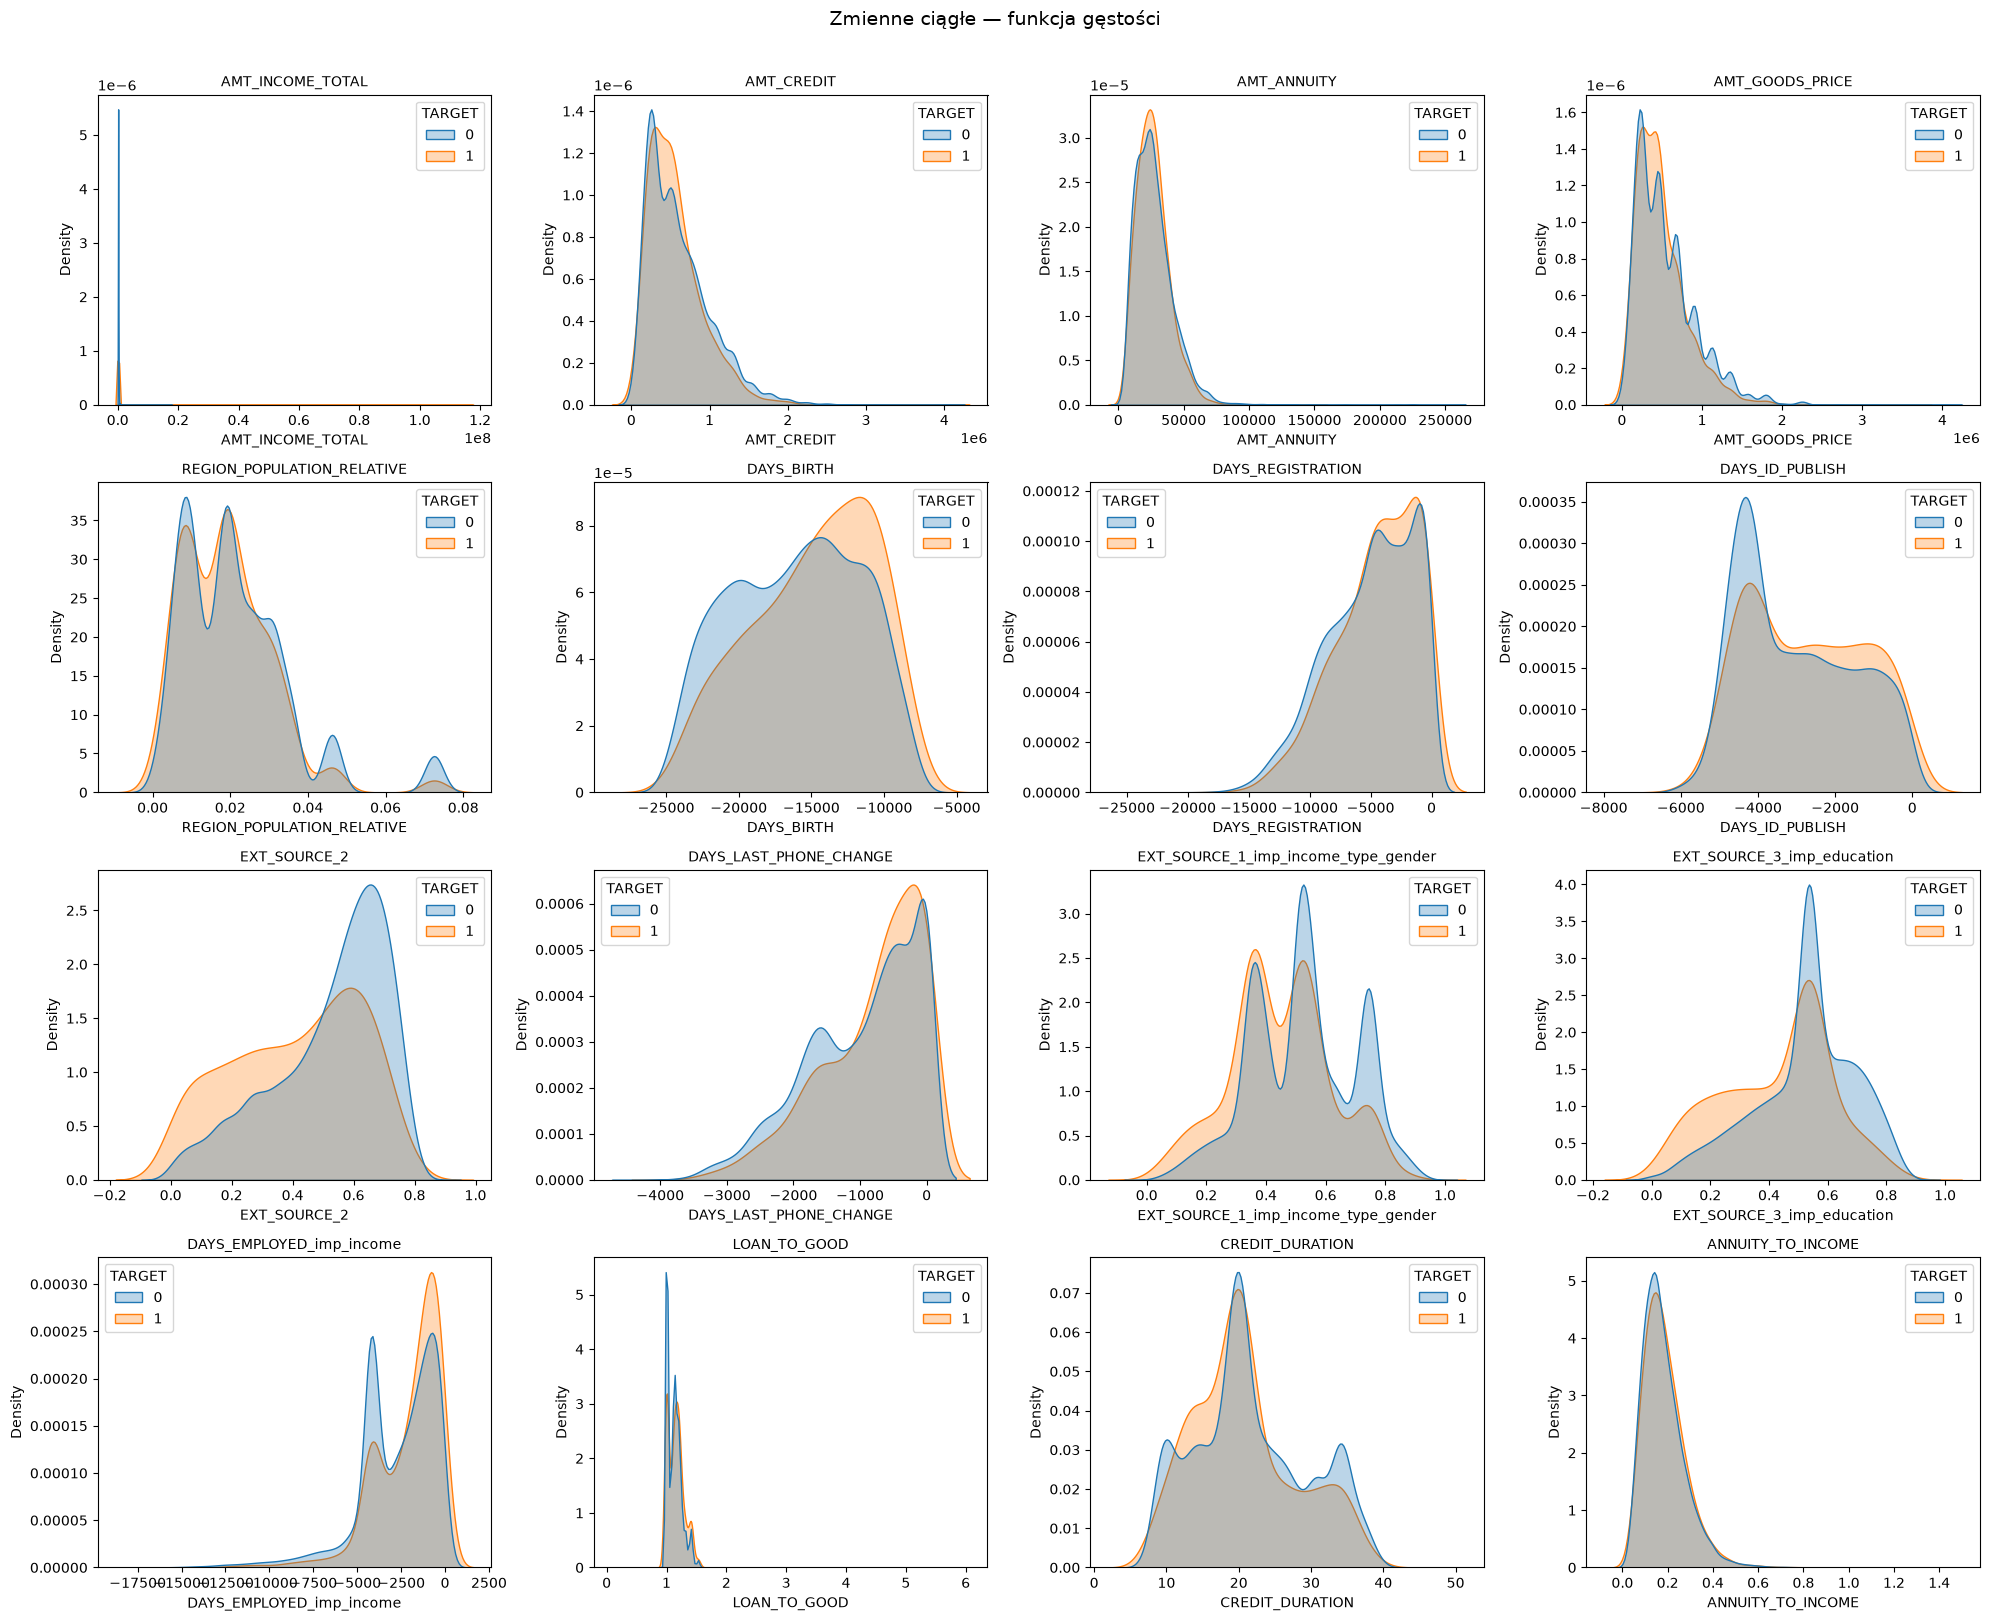

In [936]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df_train6.select_dtypes(include="number").drop(columns=["TARGET"]).columns

# Podział na binarne i ciągłe
binary_cols = [c for c in num_cols if df_train6[c].dropna().isin([0, 1]).all()]
ordinal_cols = ["REGION_RATING_CLIENT", "REGION_RATING_CLIENT_W_CITY"]

continuous_cols = [c for c in num_cols if c not in binary_cols and c not in ordinal_cols]

# Ciągłe: KDE z podziałem po TARGET ---
n = len(continuous_cols)
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    sns.kdeplot(data=df_train6, x=col, hue="TARGET", ax=axes[i], 
                fill=True, alpha=0.3, common_norm=False, bw_adjust=2)
    axes[i].set_title(col, fontsize=10)


for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Zmienne ciągłe — funkcja gęstości", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [937]:
def clip_outliers_iqr(df, columns, k=1.5, df_valid=None):
    """
    Obcina outliery metodą IQR. Granice liczone na df (train),
    a następnie stosowane też na df_valid (jeśli podany).
    
    Wartości poniżej Q1 - k*IQR zastępowane dolną granicą,
    powyżej Q3 + k*IQR — górną granicą.
    
    Returns: df, df_valid (jeśli podany), summary DataFrame
    """
    df_out = df.copy()
    df_valid_out = df_valid.copy() if df_valid is not None else None
    summary = []

    for col in columns:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - k * IQR
        upper = Q3 + k * IQR

        n_below_train = (df_out[col] < lower).sum()
        n_above_train = (df_out[col] > upper).sum()
        df_out[col] = df_out[col].clip(lower, upper)

        n_below_valid, n_above_valid = None, None
        if df_valid_out is not None:
            n_below_valid = (df_valid_out[col] < lower).sum()
            n_above_valid = (df_valid_out[col] > upper).sum()
            df_valid_out[col] = df_valid_out[col].clip(lower, upper)

        summary.append({
            "column": col,
            "Q1": Q1, "Q3": Q3, "IQR": IQR,
            "lower_bound": lower, "upper_bound": upper,
            "clipped_below_train": int(n_below_train),
            "clipped_above_train": int(n_above_train),
            "clipped_below_valid": int(n_below_valid) if n_below_valid is not None else None,
            "clipped_above_valid": int(n_above_valid) if n_above_valid is not None else None,
        })

    summary_df = pd.DataFrame(summary)

    if df_valid_out is not None:
        return df_out, df_valid_out, summary_df
    return df_out, summary_df


df_train6, df_valid6, clip_summary = clip_outliers_iqr(
    df_train6, continuous_cols, k=1.5, df_valid=df_valid6
)
clip_summary

,column,Q1,Q3,IQR,lower_bound,upper_bound,clipped_below_train,clipped_above_train,clipped_below_valid,clipped_above_valid
0,AMT_INCOME_TOTAL,112500.000000,202500.000000,90000.000000,-22500.000000,3.375000e+05,0,9856,0,4179
1,AMT_CREDIT,270000.000000,808650.000000,538650.000000,-537975.000000,1.616625e+06,0,4612,0,1950
2,AMT_ANNUITY,16524.000000,34587.000000,18063.000000,-10570.500000,6.168150e+04,0,5277,0,2229
3,AMT_GOODS_PRICE,238500.000000,679500.000000,441000.000000,-423000.000000,1.341000e+06,0,10304,0,4424
4,REGION_POPULATION_RELATIVE,0.010006,0.028663,0.018657,-0.017980,5.664850e-02,0,5875,0,2537
5,DAYS_BIRTH,-19683.000000,-12409.000000,7274.000000,-30594.000000,-1.498000e+03,0,0,0,0
6,DAYS_REGISTRATION,-7486.000000,-2017.000000,5469.000000,-15689.500000,6.186500e+03,472,0,182,0
7,DAYS_ID_PUBLISH,-4299.000000,-1721.000000,2578.000000,-8166.000000,2.146000e+03,0,0,0,0
8,EXT_SOURCE_2,0.392510,0.663476,0.270966,-0.013939,1.069924e+00,0,0,0,0
9,DAYS_LAST_PHONE_CHANGE,-1570.000000,-275.000000,1295.000000,-3512.500000,1.667500e+03,314,0,126,0


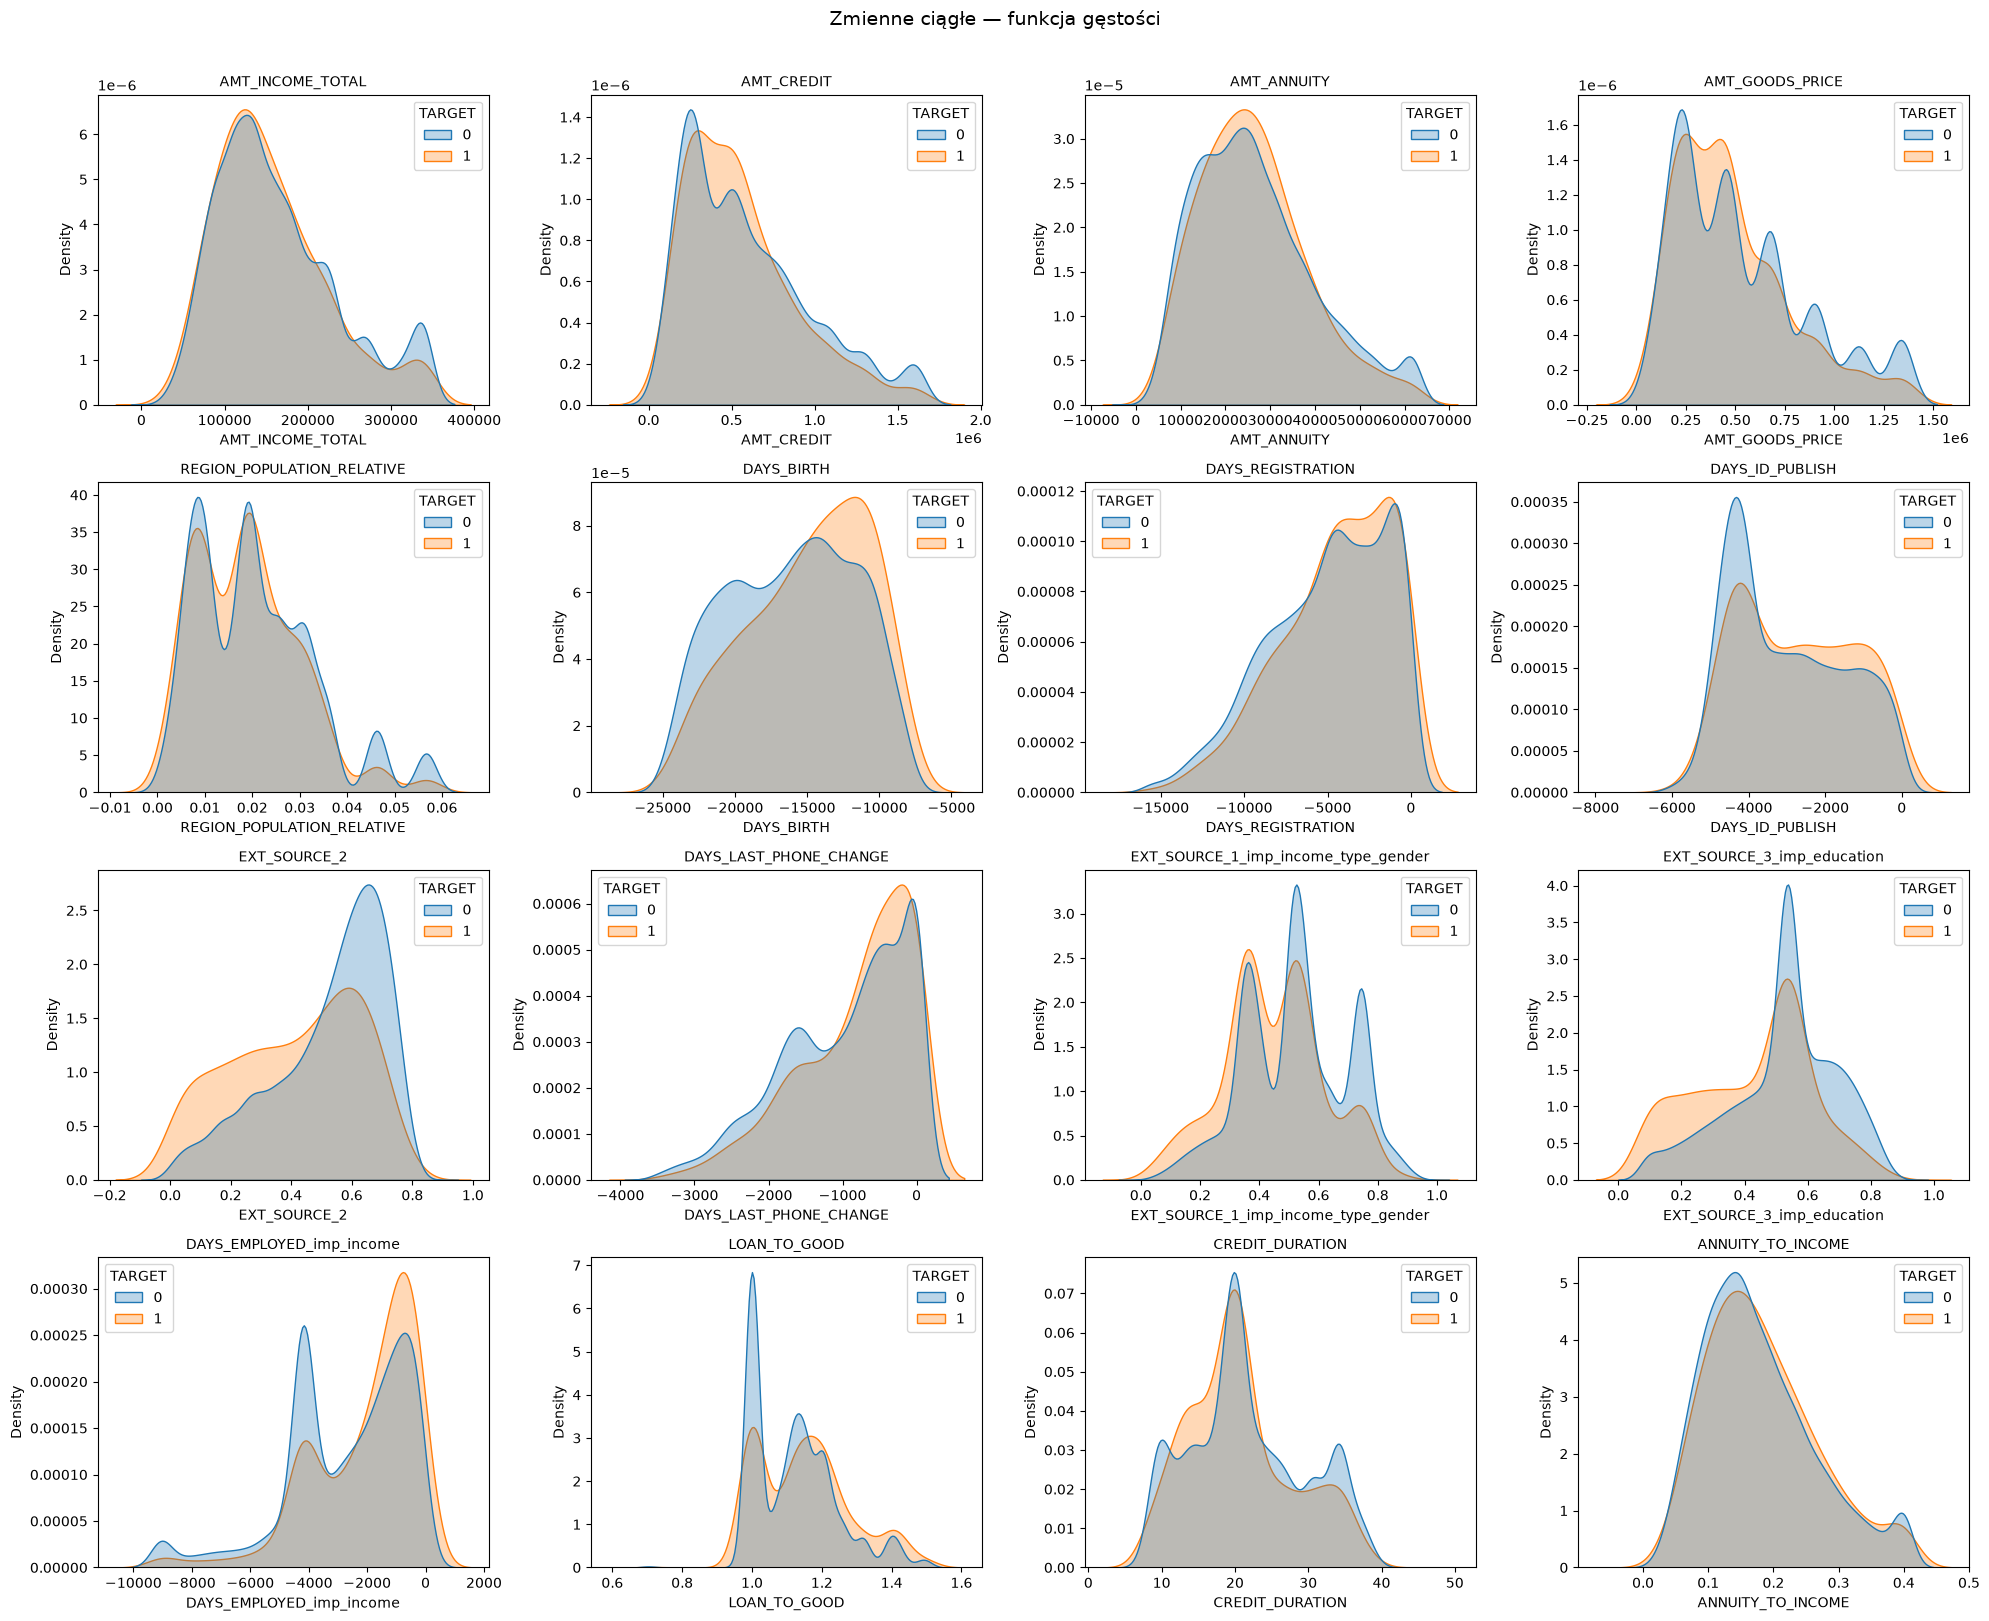

In [938]:
#wykresy gęstości po odcięciu outlierów
num_cols = df_train6.select_dtypes(include="number").drop(columns=["TARGET"]).columns

# Ciągłe: KDE z podziałem po TARGET ---
n = len(continuous_cols)
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    sns.kdeplot(data=df_train6, x=col, hue="TARGET", ax=axes[i], 
                fill=True, alpha=0.3, common_norm=False, bw_adjust=2)
    axes[i].set_title(col, fontsize=10)


for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Zmienne ciągłe — funkcja gęstości", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 8. Normalization

In [939]:
from sklearn.preprocessing import StandardScaler

# Kolumny numeryczne ciągłe do normalizacji (float64, wykluczając TARGET)
kolumny_do_normalizacji = df_train6.select_dtypes(include=['float64']).columns.tolist()

print(f"Kolumny do normalizacji ({len(kolumny_do_normalizacji)}):")
print(kolumny_do_normalizacji)

# Normalizacja (standaryzacja Z-score) — fit na train, transform na train i valid
scaler = StandardScaler()

df_train6[kolumny_do_normalizacji] = scaler.fit_transform(df_train6[kolumny_do_normalizacji])
df_valid6[kolumny_do_normalizacji] = scaler.transform(df_valid6[kolumny_do_normalizacji])

print("\nStatystyki po normalizacji (train):")
df_train6[kolumny_do_normalizacji].describe().round(3)


Kolumny do normalizacji (14):
['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_REGISTRATION', 'EXT_SOURCE_2', 'DAYS_LAST_PHONE_CHANGE', 'EXT_SOURCE_1_imp_income_type_gender', 'EXT_SOURCE_3_imp_education', 'DAYS_EMPLOYED_imp_income', 'LOAN_TO_GOOD', 'CREDIT_DURATION', 'ANNUITY_TO_INCOME']

Statystyki po normalizacji (train):


,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_REGISTRATION,EXT_SOURCE_2,DAYS_LAST_PHONE_CHANGE,EXT_SOURCE_1_imp_income_type_gender,EXT_SOURCE_3_imp_education,DAYS_EMPLOYED_imp_income,LOAN_TO_GOOD,CREDIT_DURATION,ANNUITY_TO_INCOME
count,215257.000,215257.000,215257.000,215257.000,215257.000,215257.000,215257.000,215257.000,215257.000,215257.000,215257.000,215257.000,215257.000,215257.000
mean,-0.000,0.000,0.000,0.000,0.000,-0.000,-0.000,0.000,0.000,-0.000,-0.000,-0.000,0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.870,-1.440,-1.895,-1.447,-1.627,-3.042,-2.695,-3.085,-2.894,-2.470,-3.099,-3.457,-1.957,-2.074
25%,-0.685,-0.848,-0.773,-0.859,-0.842,-0.709,-0.639,-0.734,-0.849,-0.573,-0.736,-1.007,-0.765,-0.745
50%,-0.194,-0.201,-0.142,-0.232,-0.127,0.136,0.269,0.248,-0.006,0.130,0.216,-0.028,-0.208,-0.184
75%,0.543,0.568,0.586,0.449,0.665,0.845,0.781,0.834,0.665,0.693,0.840,0.625,0.701,0.585
max,2.385,2.691,2.626,2.411,2.926,1.419,1.784,1.167,2.523,2.191,1.291,3.074,2.898,2.581


In [940]:
corr = df_train6.select_dtypes(include="number").corr()

mask = np.triu(np.ones_like(corr, dtype=bool))  # górny trójkąt
high_corr = corr.where(~mask).stack()
high_corr = high_corr[high_corr.abs() > 0.5].sort_values(key=abs, ascending=False)
high_corr

edu_secondary_incomp_higher          edu_higher_academic                   -1.000000
OWN_CAR_AGE_missing                  FLAG_OWN_CAR                          -0.999948
DAYS_EMPLOYED_special_value          FLAG_EMP_PHONE                        -0.999843
AMT_GOODS_PRICE                      AMT_CREDIT                             0.985340
REGION_RATING_CLIENT_W_CITY          REGION_RATING_CLIENT                   0.950646
LIVE_REGION_NOT_WORK_REGION          REG_REGION_NOT_WORK_REGION             0.863065
DEF_60_CNT_SOCIAL_CIRCLE_eq_0        DEF_30_CNT_SOCIAL_CIRCLE_eq_0          0.844345
LIVE_CITY_NOT_WORK_CITY              REG_CITY_NOT_WORK_CITY                 0.827718
AMT_GOODS_PRICE                      AMT_ANNUITY                            0.795138
AMT_ANNUITY                          AMT_CREDIT                             0.792967
CREDIT_DURATION                      AMT_CREDIT                             0.670123
                                     AMT_GOODS_PRICE             

## 9. Dropping unwanted columns

In [941]:
cols_to_drop = ['FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4',
       'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7',
       'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10',
       'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13',
       'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16',
       'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19',
       'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21', 'FLAG_MOBIL', 'edu_secondary_incomp_higher',
       'OWN_CAR_AGE_missing', 'DAYS_EMPLOYED_special_value', 'AMT_GOODS_PRICE', 'REGION_RATING_CLIENT_W_CITY',
       'LIVE_REGION_NOT_WORK_REGION', 'DEF_30_CNT_SOCIAL_CIRCLE_eq_0', 'REG_CITY_NOT_WORK_CITY']

df_train6.drop(columns = cols_to_drop, inplace=True)
df_valid6.drop(columns = cols_to_drop, inplace=True)

## 10. Saving preprocessed data sets

In [942]:
pd.set_option('display.max_columns', 80)
df_train6.head(20)

,NAME_CONTRACT_TYPE,FLAG_OWN_CAR,FLAG_OWN_REALTY,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,REGION_RATING_CLIENT,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_2,DAYS_LAST_PHONE_CHANGE,TARGET,NAME_TYPE_SUITE_grouped,NAME_HOUSING_TYPE_grouped,OCCUPATION_TYPE_grouped,ORGANIZATION_TYPE_grouped,NAME_INCOME_TYPE_grouped,edu_higher_academic,NAME_FAMILY_STATUS_grouped,CNT_CHILDREN_grouped,2_fam_members,OBS_30_CNT_SOCIAL_CIRCLE_grouped,OBS_60_CNT_SOCIAL_CIRCLE_grouped,DEF_60_CNT_SOCIAL_CIRCLE_eq_0,AMT_REQ_CREDIT_BUREAU_YEAR_grouped,EXT_SOURCE_1_missing,EXT_SOURCE_1_imp_income_type_gender,EXT_SOURCE_3_missing,EXT_SOURCE_3_imp_education,DAYS_EMPLOYED_imp_income,CODE_GENDER_imputed,LOAN_TO_GOOD,CREDIT_DURATION,ANNUITY_TO_INCOME
0,1,1,1,2.384830,2.691467,2.625602,-1.096741,-13587,-0.701953,-1823,1,0,1,0,0,3,0,0,0,0,-0.978373,-1.458475,0,Unaccompanied,1,Accountants,Self-employed,Commercial associate,1,Married,>=2,0,>=2,>=2,1,0.0,0,0.925161,0,0.730885,0.793283,1,-0.223767,0.907196,-0.103730
1,1,0,1,2.384830,-0.221333,0.854281,-0.820123,-17543,0.266364,-1090,1,0,1,0,0,2,0,0,0,0,0.541469,0.369079,0,Family,1,Managers,other,State_servant,1,Married,0,1,>=2,>=2,0,>=4,1,-0.788313,0,-0.440179,0.706138,0,-0.027824,-1.061163,-0.760816
2,1,0,1,-0.685376,-1.268422,-1.033210,-1.239574,-11557,-0.160082,-4130,1,0,1,1,1,2,0,0,0,0,0.698172,0.958495,0,Unaccompanied,1,Laborers,Business Entity Type 3,Commercial associate,0,Married,1,0,0.0,0.0,1,missing,0,-0.908356,1,0.129896,1.003883,0,0.838411,-1.688252,-0.724351
3,1,0,1,-1.667842,-1.383455,-1.751899,0.880708,-15750,-0.083606,-5290,1,0,1,0,0,2,0,0,0,0,0.457493,-0.740767,0,Unaccompanied,1,Sales staff,Self-employed,Commercial associate,0,Married,>=2,0,0.0,0.0,1,2-3,0,-0.749177,0,-0.388803,-1.311747,1,2.911063,-0.353083,-1.064998
4,1,1,0,0.849727,-0.773290,0.376735,-0.107168,-19912,1.394457,-3033,1,0,1,0,0,2,0,0,0,0,0.744842,0.411439,0,Unaccompanied,1,Drivers,other,Commercial associate,0,Married,0,1,>=2,>=2,1,0.0,0,1.285783,0,1.172067,0.712432,0,-0.136688,-1.565683,-0.431316
5,1,0,1,2.077809,-0.461772,-0.363630,-0.830544,-15714,1.371997,-3973,1,0,1,0,0,2,0,0,0,0,-1.751161,0.375130,0,Unaccompanied,1,Laborers,other,Working,0,Civil marriage / Single / not married,0,0,0.0,0.0,1,2-3,0,-2.266872,0,-1.959950,-1.185871,1,0.298705,-0.337496,-1.264703
6,1,1,1,-0.009931,-1.116082,-1.161572,-0.872312,-18089,-0.572882,-1623,1,0,1,0,0,2,0,0,0,1,-1.349700,1.166666,0,other,1,Drivers,Business Entity Type 3,Working,0,Married,0,1,0.0,0.0,1,1.0,0,-1.666807,0,-0.984107,-0.647026,0,0.081008,-0.873807,-1.259928
7,1,0,1,-0.378356,1.411023,0.468857,-0.420626,-14648,1.076896,-4310,1,1,1,1,0,2,0,0,0,0,0.232627,0.589353,0,other,1,missing / core staff,Self-employed,Working,0,Married,0,1,1.0,1.0,1,missing,1,-0.006215,1,0.129896,1.198022,1,-1.007474,1.609088,0.770774
8,1,0,1,-0.071335,1.755898,0.972143,0.834336,-19306,-1.114185,-2855,1,0,1,0,0,2,0,0,0,0,0.501857,-2.515067,0,Unaccompanied,1,Medicine staff,other,State_servant,0,Widow,0,0,>=2,>=2,1,1.0,1,0.324088,0,1.748039,1.139441,1,-0.049615,1.294975,0.858167
9,1,1,0,0.235686,0.753827,-0.071684,-1.148849,-16260,-0.699963,-4209,1,0,1,0,0,2,0,0,0,0,1.207621,-0.726243,0,Unaccompanied,1,Laborers,Business Entity Type 3,Working,0,Separated,0,0,>=2,>=2,1,2-3,0,-0.862963,0,-1.505994,0.205056,1,2.257974,1.587357,-0.405306


In [943]:
PROJECT_PATH = Path.cwd()
DATA_SAVE_PATH = PROJECT_PATH / 'data'

if str(DATA_SAVE_PATH) not in sys.path:
    sys.path.insert(0, str(DATA_SAVE_PATH))

DATA_SAVE_PATH.mkdir(parents=True, exist_ok=True)

In [944]:
df_train6.to_csv(DATA_SAVE_PATH / 'app_train_processed.csv', index=False)
print(f"app_train_df saved to: DATA_SAVE_PATH\\app_train_processed.csv")

df_valid6.to_csv(DATA_SAVE_PATH / 'app_valid_processed.csv', index=False)
print(f"app_valid_df saved to: DATA_SAVE_PATH\\app_train_processed.csv")

app_train_df saved to: DATA_SAVE_PATH\app_train_processed.csv
app_valid_df saved to: DATA_SAVE_PATH\app_train_processed.csv


In [945]:
df_train6.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215257 entries, 0 to 215256
Data columns (total 45 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   NAME_CONTRACT_TYPE                   215257 non-null  int64  
 1   FLAG_OWN_CAR                         215257 non-null  int64  
 2   FLAG_OWN_REALTY                      215257 non-null  int64  
 3   AMT_INCOME_TOTAL                     215257 non-null  float64
 4   AMT_CREDIT                           215257 non-null  float64
 5   AMT_ANNUITY                          215257 non-null  float64
 6   REGION_POPULATION_RELATIVE           215257 non-null  float64
 7   DAYS_BIRTH                           215257 non-null  int64  
 8   DAYS_REGISTRATION                    215257 non-null  float64
 9   DAYS_ID_PUBLISH                      215257 non-null  int64  
 10  FLAG_EMP_PHONE                       215257 non-null  int64  
 11  FLAG_WORK_PHO